<a href="https://colab.research.google.com/github/jeffersonbuendia/dbp-mortality-calculator/blob/main/tarea_predictivos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# =========================================================
# MODELO PREDICTIVO TEMPRANO DE MORTALIDAD INTRAHOSPITALARIA
# FASE 1: CARGA, DEPURACIÓN INICIAL Y DEFINICIÓN DE VARIABLES TEMPRANAS
# =========================================================

import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1. CARGA DE LA BASE
# ---------------------------------------------------------
# Fundamento:
# Primero verificamos que el archivo abre bien, qué hojas contiene,
# y trabajamos sobre la hoja original/no editada.
# Esto permite conservar el máximo de información candidata para
# el modelo predictivo temprano.

file_path = "/content/drive/MyDrive/Drive/En proceso de publicacion/ARTICULOS PRIMERA Y SEGUNDA FASE/PRIMERA FASE/DBP/Bolivariana/Displasia broncopulmonar version original V2.xlsx"

xls = pd.ExcelFile(file_path)
print("Hojas disponibles:", xls.sheet_names)

df = pd.read_excel(file_path, sheet_name="Edited")

print("Dimensión inicial:", df.shape)
display(df.head(3))


# ---------------------------------------------------------
# 2. RENOMBRAR VARIABLES CLAVE
# ---------------------------------------------------------
# Fundamento:
# Los nombres originales del Excel son muy largos. Renombrarlos mejora
# la seguridad del análisis, facilita los gráficos, tablas, modelos,
# y reduce errores en recodificación e imputación.

rename_dict = {
    "Identificación del paciente (número de historia clínica, pegado, sin comas ni puntos, número entero)": "id_paciente",
    "¿El paciente murió durante la hospitalización?": "muerte_hosp",
    "Edad de la madre (años cumplidos, solo números enteros, sin comas ni números)": "edad_materna",
    "La madre tiene historia personal de Diabetes Mellitus:": "dm_materna",
    "La madre tiene historia personal de Diabetes Gestacional:": "dm_gestacional",
    "La madre tiene historia de hipertensión crónica o hipertensión gestacional:": "hta_materna",
    "La madre tiene historia de consumo de tabaco durante el embarazo:": "tabaco_embarazo",
    "La madre tiene historia de consumo de psicoactivos durante el embarazo:": "psicoactivos_embarazo",
    "Diagnóstico prenatal de RCIU (Peso fetal estimado menor al percentil 3 o peso fetal estimado entre el percentil 3 y 10 con doppler alterado)": "rciu_prenatal",
    "Tipo de retraso de crecimiento fetal (previo RCIU) Si no tiene RCIU o no dice que tipo de RCIU es dejar en blanco": "tipo_rciu",
    "Reporte de oligoamnios o ILA menor o igual a 5 en la última ecografía reportada:": "oligoamnios",
    "Recibió maduración fetal? (la madre recibió dexametasona o betametasona intramuscular antes del parto)": "maduracion_fetal",
    "Esquema recibido de maduración fetal: Si no recibió maduración dejar en blanco": "esquema_maduracion",
    "¿Hubo sospecha o confirmación de infección o inflamación intraamniótica? (Fiebre materna >39° periparto O fiebre materna + uno de los siguientes 1. Leucocitosis >15.000, 2. Taquicardia materna, 3. Dolor uterino, 4. Líquido amniótico fétido, 5. Taquicardia fetal)": "infeccion_intraamniotica",
    "Número de fetos en el embarazo actual (última ecografía):": "num_fetos",
    "Latencia de ruptura de membranas (horas transcurridas entre la ruptura de membranas ovulares y el nacimiento). Poner números enteros. Redondear al número entero más próximo. ": "latencia_rpm_horas",
    "Número de semanas de gestación en el momento del parto por ecografía del primer trimestre o la primera realizada. Si no es posible, por Ballard\n\nPoner el número de semanas cumplidas completas, adicionar un excedente por cada día de la semana adicional): \nClave\n+0: 0.14 +1: 0.28 +2: 0.43 +3: 0.57 + 4: 0.71 +5: 0.85 +6: 0.99\n\nEjemplo: nació a las 34+4 semanas, escribir 34.71": "edad_gestacional",
    "¿Fue el paciente prematuro extremo? (edad gestacional al nacimiento menor de 28 semanas)": "prematuro_extremo",
    "Peso documentado en sala de partos en gramos (números enteros sin decimales ni signos de puntuación)": "peso_nacer_g",
    "Sexo definido por genitales del paciente:": "sexo",
    "Talla documentada en sala de partos en centímetros (usar un solo decimal separado por un punto)": "talla_nacer_cm",
    "Percentil documentado en la historia clínica del nacimiento del peso al nacer según Intergrowth  (usar un solo decimal separado por un punto)": "percentil_peso_nacer",
    "Puntaje APGAR al minuto de vida": "apgar_1",
    "Puntaje APGAR a los 5 minutos de vida": "apgar_5",
    "Vía del parto": "via_parto",
    "¿Requirió intubación en sala de partos?": "intubacion_sala",
    "¿Requirió ventilación con presión positiva o CPAP en sala de partos?": "vpp_cpap_sala",
    "¿Requirió compresiones torácicas en sala de parto?": "compresiones_sala",
    "¿Requirió reanimación con adrenalina en sala de partos?": "adrenalina_sala",
    " Numero de controles prenatales (número entero)": "controles_prenatales",
    "¿El último doppler registrado presenta alteraciones en las arterias uterinas o fetales? Si no tiene doppler dejar opción en blanco": "doppler_alterado",
    "La madre tiene historia de preeclampsia no grave durante la gestación:": "preeclampsia_no_grave",
    "La madre tiene historia de preeclampsia grave durante la gestación:": "preeclampsia_grave",
    "La madre tiene historia de síndrome de HELLP o eclampsia durante la gestación:": "hellp_eclampsia",
    "Causa de la prematurez del bebé (si hay dudas sobre cual causa poner preguntar a sofia o andrea)": "causa_prematurez"
}

df = df.rename(columns=rename_dict)

print("Columnas renombradas detectadas:", sum([c in rename_dict.values() for c in df.columns]))


# ---------------------------------------------------------
# 3. DEFINICIÓN DEL CONJUNTO DE VARIABLES TEMPRANAS
# ---------------------------------------------------------
# Fundamento:
# Solo incluimos variables disponibles antes o inmediatamente en el
# nacimiento/reanimación inicial. No se deben usar variables de evolución
# intrahospitalaria porque causarían fuga temporal.

early_vars = [
    "id_paciente",
    "muerte_hosp",

    # Maternas / prenatales
    "edad_materna",
    "dm_materna",
    "dm_gestacional",
    "hta_materna",
    "tabaco_embarazo",
    "psicoactivos_embarazo",
    "controles_prenatales",
    "doppler_alterado",
    "rciu_prenatal",
    "tipo_rciu",
    "oligoamnios",
    "maduracion_fetal",
    "esquema_maduracion",
    "infeccion_intraamniotica",
    "num_fetos",
    "latencia_rpm_horas",
    "preeclampsia_no_grave",
    "preeclampsia_grave",
    "hellp_eclampsia",
    "causa_prematurez",

    # Neonatales al nacimiento
    "edad_gestacional",
    "prematuro_extremo",
    "peso_nacer_g",
    "sexo",
    "talla_nacer_cm",
    "percentil_peso_nacer",
    "apgar_1",
    "apgar_5",
    "via_parto",

    # Sala de partos / reanimación inmediata
    "intubacion_sala",
    "vpp_cpap_sala",
    "compresiones_sala",
    "adrenalina_sala",
]

# Conservamos solo las columnas existentes
existing_early_vars = [c for c in early_vars if c in df.columns]
missing_early_vars = [c for c in early_vars if c not in df.columns]

print("Variables tempranas encontradas:", len(existing_early_vars))
print("Variables tempranas NO encontradas:", missing_early_vars)

df_early = df[existing_early_vars].copy()
print("Dimensión base temprana:", df_early.shape)
display(df_early.head(3))


# ---------------------------------------------------------
# 4. REVISIÓN DE DUPLICADOS POR PACIENTE
# ---------------------------------------------------------
# Fundamento:
# En modelos clínicos, la unidad de análisis debe ser una fila por paciente.
# Los duplicados pueden inflar el tamaño muestral y sesgar el modelo.

dup_mask = df_early["id_paciente"].duplicated(keep=False)
dups = df_early.loc[dup_mask].sort_values("id_paciente")

print("Número de filas con ID duplicado:", dups.shape[0])
print("Número de IDs duplicados:", dups["id_paciente"].nunique())

if dups.shape[0] > 0:
    display(dups)

    print("\nComparación de diferencias entre duplicados:")
    for pid, grp in dups.groupby("id_paciente"):
        print(f"\n=== ID: {pid} ===")
        temp = grp.copy()
        diff_cols = [c for c in temp.columns if temp[c].nunique(dropna=False) > 1]
        print("Columnas con diferencias:", diff_cols)


# ---------------------------------------------------------
# 5. RECODIFICACIÓN BINARIA
# ---------------------------------------------------------
# Fundamento:
# Para modelos logísticos, las variables binarias y el outcome deben tener
# una codificación consistente. Aquí intentamos mapear respuestas tipo sí/no
# a 1/0.

def recode_si_no(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower()
    if x in ["sí", "si", "yes", "1", "true", "verdadero"]:
        return 1
    if x in ["no", "0", "false", "falso"]:
        return 0
    return np.nan

binary_cols = [
    "muerte_hosp",
    "dm_materna",
    "dm_gestacional",
    "hta_materna",
    "tabaco_embarazo",
    "psicoactivos_embarazo",
    "rciu_prenatal",
    "oligoamnios",
    "maduracion_fetal",
    "infeccion_intraamniotica",
    "prematuro_extremo",
    "intubacion_sala",
    "vpp_cpap_sala",
    "compresiones_sala",
    "adrenalina_sala",
    "doppler_alterado",
    "preeclampsia_no_grave",
    "preeclampsia_grave",
    "hellp_eclampsia"
]

for col in binary_cols:
    if col in df_early.columns:
        df_early[col] = df_early[col].apply(recode_si_no)

print("\nDistribución preliminar de muerte_hosp:")
print(df_early["muerte_hosp"].value_counts(dropna=False))
print("Proporción preliminar de muerte:", df_early["muerte_hosp"].mean())


# ---------------------------------------------------------
# 6. CONVERSIÓN DE VARIABLES NUMÉRICAS
# ---------------------------------------------------------
# Fundamento:
# Muchos archivos Excel combinan texto y números en la misma columna.
# Antes de describir o imputar, debemos forzar tipo numérico donde aplica.

numeric_cols = [
    "edad_materna",
    "controles_prenatales",
    "num_fetos",
    "latencia_rpm_horas",
    "edad_gestacional",
    "peso_nacer_g",
    "talla_nacer_cm",
    "percentil_peso_nacer",
    "apgar_1",
    "apgar_5"
]

for col in numeric_cols:
    if col in df_early.columns:
        df_early[col] = pd.to_numeric(df_early[col], errors="coerce")

print("\nTipos numéricos:")
print(df_early[[c for c in numeric_cols if c in df_early.columns]].dtypes)


# ---------------------------------------------------------
# 7. TABLA DE DATOS FALTANTES
# ---------------------------------------------------------
# Fundamento:
# Antes de seleccionar predictores o imputar, hay que cuantificar la magnitud
# de los faltantes y ver si algunas variables son inviables para el modelo.

missing_table = pd.DataFrame({
    "variable": df_early.columns,
    "n_missing": df_early.isna().sum().values,
    "pct_missing": (df_early.isna().mean().values * 100).round(1),
    "n_unique_non_missing": [df_early[c].nunique(dropna=True) for c in df_early.columns]
}).sort_values("pct_missing", ascending=False)

print("\nTabla de faltantes:")
display(missing_table)


# ---------------------------------------------------------
# 8. FRECUENCIAS BÁSICAS DE VARIABLES CLAVE
# ---------------------------------------------------------
# Fundamento:
# Esto nos ayuda a identificar categorías raras, problemas de codificación,
# y plausibilidad clínica de las variables candidatas.

key_cols = ["prematuro_extremo", "sexo", "intubacion_sala", "vpp_cpap_sala", "causa_prematurez"]

for col in key_cols:
    if col in df_early.columns:
        print(f"\n===== {col} =====")
        print(df_early[col].value_counts(dropna=False))


# ---------------------------------------------------------
# 9. GUARDAR LA BASE TEMPRANA DEPURADA PRELIMINAR
# ---------------------------------------------------------
# Fundamento:
# Esta versión todavía no es la final para modelar, pero ya es la primera
# base analítica temprana. La guardamos para trazabilidad del proceso.

output_path = "/content/drive/MyDrive/Drive/En proceso de publicacion/ARTICULOS PRIMERA Y SEGUNDA FASE/PRIMERA FASE/DBP/Bolivariana/dbp_early_preliminar_python.xlsx"
df_early.to_excel(output_path, index=False)

print("\nArchivo guardado en:")
print(output_path)

Hojas disponibles: ['Edited']
Dimensión inicial: (236, 104)


,ID,"Identificación del paciente (número de historia clínica, pegado, sin comas ni puntos, número entero)",Días de estancia hospitalaria:,"Días totales de estancia en UCI (contar solo los días de UCIN, no UCEN ni básicos)",Estrato socio-económico de la madre,Escolaridad materna,"Edad de la madre (años cumplidos, solo números enteros, sin comas ni números)",Procedencia de la madre,EPS,La madre tiene historia personal de Diabetes Mellitus:,...,El paciente fue dado de alta antes de la semana 36,¿El paciente presentó anemia con requerimiento transfusional durante la hospitalización?,Percentil documentado en la historia clínica del nacimiento de la talla al nacer según Intergrowth (usar un solo decimal separado por un punto),La madre tiene historia de preeclampsia 0 grave durante la gestación:,La madre tiene historia de preeclampsia grave durante la gestación:,La madre tiene historia de 1ndrome de HELLP o eclampsia durante la gestación:,Causa de la prematurez del bebé,"El paciente tiene diagnóstico de DBP potencialmente fatal: es definida como uso de presión positiva (IOT, VNI) o uso de vasodilatadores pulmonares a la semana 38",Death,Cuál fue la causa de muerte descrita en la historia clínica
0,1.0,818989.0,45.0,20.0,1.0,NaN,18.0,1.0,1.0,0.0,...,1.0,1.0,38.2,0.0,0.0,0.0,1.0,0.0,0.0,NaN
1,2.0,823985.0,2.0,2.0,NaN,NaN,17.0,1.0,0.0,0.0,...,0.0,0.0,93.7,0.0,0.0,0.0,0.0,NaN,1.0,3.0
2,3.0,823986.0,4.0,4.0,NaN,NaN,17.0,1.0,0.0,0.0,...,0.0,1.0,12.2,0.0,0.0,0.0,0.0,NaN,1.0,2.0


Columnas renombradas detectadas: 26
Variables tempranas encontradas: 26
Variables tempranas NO encontradas: ['doppler_alterado', 'rciu_prenatal', 'tipo_rciu', 'esquema_maduracion', 'infeccion_intraamniotica', 'preeclampsia_no_grave', 'hellp_eclampsia', 'causa_prematurez', 'edad_gestacional']
Dimensión base temprana: (236, 26)


,id_paciente,muerte_hosp,edad_materna,dm_materna,dm_gestacional,hta_materna,tabaco_embarazo,psicoactivos_embarazo,controles_prenatales,oligoamnios,...,sexo,talla_nacer_cm,percentil_peso_nacer,apgar_1,apgar_5,via_parto,intubacion_sala,vpp_cpap_sala,compresiones_sala,adrenalina_sala
0,818989.0,0.0,18.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,37.0,63.7,7.0,8.0,1.0,1.0,1.0,0.0,0.0
1,823985.0,1.0,17.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,...,1.0,42.0,45.1,4.0,7.0,1.0,1.0,1.0,1.0,1.0
2,823986.0,1.0,17.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,...,1.0,35.0,0.2,6.0,8.0,1.0,1.0,1.0,0.0,0.0


Número de filas con ID duplicado: 6
Número de IDs duplicados: 3


,id_paciente,muerte_hosp,edad_materna,dm_materna,dm_gestacional,hta_materna,tabaco_embarazo,psicoactivos_embarazo,controles_prenatales,oligoamnios,...,sexo,talla_nacer_cm,percentil_peso_nacer,apgar_1,apgar_5,via_parto,intubacion_sala,vpp_cpap_sala,compresiones_sala,adrenalina_sala
91,848794.0,0.0,35.0,0.0,0.0,0.0,0.0,0.0,7.0,0.0,...,0.0,37.0,45.4,7.0,8.0,1.0,1.0,1.0,0.0,0.0
90,848794.0,0.0,25.0,0.0,0.0,0.0,0.0,0.0,7.0,0.0,...,0.0,37.0,45.4,7.0,8.0,1.0,1.0,1.0,0.0,0.0
196,848959.0,0.0,20.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,...,1.0,31.0,26.6,1.0,8.0,1.0,1.0,1.0,0.0,0.0
195,848959.0,0.0,20.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,...,1.0,31.0,26.6,1.0,8.0,1.0,1.0,1.0,0.0,0.0
63,849129.0,0.0,35.0,0.0,0.0,1.0,0.0,0.0,5.0,1.0,...,1.0,38.0,15.7,6.0,8.0,0.0,1.0,1.0,0.0,0.0
64,849129.0,0.0,35.0,0.0,0.0,1.0,0.0,0.0,5.0,1.0,...,1.0,38.0,15.7,6.0,8.0,0.0,1.0,1.0,0.0,0.0



Comparación de diferencias entre duplicados:

=== ID: 848794.0 ===
Columnas con diferencias: ['edad_materna']

=== ID: 848959.0 ===
Columnas con diferencias: []

=== ID: 849129.0 ===
Columnas con diferencias: []

Distribución preliminar de muerte_hosp:
muerte_hosp
NaN    236
Name: count, dtype: int64
Proporción preliminar de muerte: nan

Tipos numéricos:
edad_materna            float64
controles_prenatales    float64
num_fetos               float64
latencia_rpm_horas      float64
peso_nacer_g            float64
talla_nacer_cm          float64
percentil_peso_nacer    float64
apgar_1                 float64
apgar_5                 float64
dtype: object

Tabla de faltantes:


,variable,n_missing,pct_missing,n_unique_non_missing
1,muerte_hosp,236,100.0,0
3,dm_materna,236,100.0,0
9,oligoamnios,236,100.0,0
4,dm_gestacional,236,100.0,0
5,hta_materna,236,100.0,0
6,tabaco_embarazo,236,100.0,0
7,psicoactivos_embarazo,236,100.0,0
14,prematuro_extremo,236,100.0,0
13,preeclampsia_grave,236,100.0,0
10,maduracion_fetal,236,100.0,0



===== prematuro_extremo =====
prematuro_extremo
NaN    236
Name: count, dtype: int64

===== sexo =====
sexo
1.0    122
0.0    112
NaN      2
Name: count, dtype: int64

===== intubacion_sala =====
intubacion_sala
NaN    236
Name: count, dtype: int64

===== vpp_cpap_sala =====
vpp_cpap_sala
NaN    236
Name: count, dtype: int64

Archivo guardado en:
/content/drive/MyDrive/Drive/En proceso de publicacion/ARTICULOS PRIMERA Y SEGUNDA FASE/PRIMERA FASE/DBP/Bolivariana/dbp_early_preliminar_python.xlsx


In [3]:
# =========================================================
# MODELO PREDICTIVO TEMPRANO DE MORTALIDAD INTRAHOSPITALARIA
# FASE 1: AUDITORÍA, DEPURACIÓN Y DEFINICIÓN DE VARIABLES TEMPRANAS
# =========================================================

# ---------------------------------------------------------
# FUNDAMENTO GENERAL
# ---------------------------------------------------------
# En esta etapa NO estamos ajustando el modelo aún.
# Primero debemos verificar:
# 1) qué columnas existen realmente en la base,
# 2) cómo están codificadas,
# 3) cuál es el outcome correcto,
# 4) si hay duplicados por paciente,
# 5) qué variables son válidas para predicción temprana,
# 6) cuántos faltantes hay.
#
# Esta fase es crítica porque un modelo predictivo solo es tan bueno
# como la calidad y validez temporal de las variables que lo alimentan.
# Además, debemos evitar "fuga temporal": no incluir variables que
# solo se conocen después de iniciada la evolución hospitalaria.

# =========================================================
# 0. LIBRERÍAS
# =========================================================
import pandas as pd
import numpy as np

# =========================================================
# 1. CARGA DEL ARCHIVO
# =========================================================
file_path = "/content/drive/MyDrive/Drive/En proceso de publicacion/ARTICULOS PRIMERA Y SEGUNDA FASE/PRIMERA FASE/DBP/Bolivariana/Displasia broncopulmonar version original V2.xlsx"

xls = pd.ExcelFile(file_path)
print("Hojas disponibles:", xls.sheet_names)

# En esta versión el archivo tiene hoja 'Edited'
df = pd.read_excel(file_path, sheet_name="Edited")

print("\nDimensión inicial de la base:", df.shape)
display(df.head(3))

# =========================================================
# 2. AUDITORÍA GLOBAL DE NOMBRES DE COLUMNAS
# =========================================================
# Fundamento:
# Antes de renombrar o recodificar, debemos ver exactamente cómo se llaman
# las variables en ESTA versión del archivo.

print("\n====================")
print("LISTADO COMPLETO DE COLUMNAS")
print("====================")
all_cols = pd.DataFrame({"columnas_originales": df.columns})
display(all_cols)

# Búsqueda orientada por palabras clave
keywords = [
    "death", "mur", "muerte",
    "gest", "prematur", "edad gest",
    "rciu", "crecimiento",
    "amnio", "infeccion", "corio",
    "madur",
    "doppler",
    "parto",
    "intub",
    "cpap",
    "ventil",
    "adrenal",
    "apgar",
    "peso",
    "talla",
    "sexo",
    "oligo",
    "hellp",
    "preecl",
    "hipert",
    "controles",
    "prenat"
]

print("\n====================")
print("BÚSQUEDA DE COLUMNAS POR PALABRAS CLAVE")
print("====================")
for kw in keywords:
    matches = [c for c in df.columns if kw.lower() in c.lower()]
    if matches:
        print(f"\n### Coincidencias para '{kw}':")
        for m in matches:
            print("-", m)

# =========================================================
# 3. INSPECCIÓN DE CODIFICACIÓN REAL DE VARIABLES CLAVE
# =========================================================
# Fundamento:
# En la salida previa vimos que muchas variables quedaron 100% NaN
# luego de recodificarlas como si/no.
# Eso sugiere que están codificadas de otra forma (por ejemplo 0/1, 1/2,
# o como una variable derivada llamada 'Death').
# Por eso primero inspeccionamos la codificación real antes de transformar.

candidate_cols = [
    "Death",
    "¿El paciente murió durante la hospitalización?",
    "Sexo definido por genitales del paciente:",
    "Peso documentado en sala de partos en gramos (números enteros sin decimales ni signos de puntuación)",
    "Puntaje APGAR al minuto de vida",
    "Puntaje APGAR a los 5 minutos de vida",
    "Vía del parto",
    "¿Requirió intubación en sala de partos?",
    "¿Requirió ventilación con presión positiva o CPAP en sala de partos?",
    "¿Requirió compresiones torácicas en sala de parto?",
    "¿Requirió reanimación con adrenalina en sala de partos?",
    "¿Fue el paciente prematuro extremo? (edad gestacional al nacimiento menor de 28 semanas)",
    "Edad de la madre (años cumplidos, solo números enteros, sin comas ni números)"
]

print("\n====================")
print("INSPECCIÓN DE CODIFICACIÓN REAL")
print("====================")
for col in candidate_cols:
    if col in df.columns:
        print(f"\n===== {col} =====")
        print(df[col].value_counts(dropna=False).head(20))

# =========================================================
# 4. RENOMBRADO FLEXIBLE DE VARIABLES CLAVE
# =========================================================
# Fundamento:
# Como el archivo puede variar entre versiones, aquí usamos un enfoque
# flexible: solo renombramos las columnas que realmente existan.

rename_candidates = {
    "Identificación del paciente (número de historia clínica, pegado, sin comas ni puntos, número entero)": "id_paciente",
    "Death": "muerte_hosp",
    "¿El paciente murió durante la hospitalización?": "muerte_hosp_alt",
    "Edad de la madre (años cumplidos, solo números enteros, sin comas ni números)": "edad_materna",
    "La madre tiene historia personal de Diabetes Mellitus:": "dm_materna",
    "La madre tiene historia personal de Diabetes Gestacional:": "dm_gestacional",
    "La madre tiene historia de hipertensión crónica o hipertensión gestacional:": "hta_materna",
    "La madre tiene historia de consumo de tabaco durante el embarazo:": "tabaco_embarazo",
    "La madre tiene historia de consumo de psicoactivos durante el embarazo:": "psicoactivos_embarazo",
    " Numero de controles prenatales (número entero)": "controles_prenatales",
    "Reporte de oligoamnios o ILA menor o igual a 5 en la última ecografía reportada:": "oligoamnios",
    "Recibió maduración fetal? (la madre recibió dexametasona o betametasona intramuscular antes del parto)": "maduracion_fetal",
    "Número de fetos en el embarazo actual (última ecografía):": "num_fetos",
    "Latencia de ruptura de membranas (horas transcurridas entre la ruptura de membranas ovulares y el nacimiento). Poner números enteros. Redondear al número entero más próximo. ": "latencia_rpm_horas",
    "¿Fue el paciente prematuro extremo? (edad gestacional al nacimiento menor de 28 semanas)": "prematuro_extremo",
    "Peso documentado en sala de partos en gramos (números enteros sin decimales ni signos de puntuación)": "peso_nacer_g",
    "Sexo definido por genitales del paciente:": "sexo",
    "Talla documentada en sala de partos en centímetros (usar un solo decimal separado por un punto)": "talla_nacer_cm",
    "Percentil documentado en la historia clínica del nacimiento del peso al nacer según Intergrowth  (usar un solo decimal separado por un punto)": "percentil_peso_nacer",
    "Puntaje APGAR al minuto de vida": "apgar_1",
    "Puntaje APGAR a los 5 minutos de vida": "apgar_5",
    "Vía del parto": "via_parto",
    "¿Requirió intubación en sala de partos?": "intubacion_sala",
    "¿Requirió ventilación con presión positiva o CPAP en sala de partos?": "vpp_cpap_sala",
    "¿Requirió compresiones torácicas en sala de parto?": "compresiones_sala",
    "¿Requirió reanimación con adrenalina en sala de partos?": "adrenalina_sala",
    "La madre tiene historia de preeclampsia grave durante la gestación:": "preeclampsia_grave"
}

rename_dict = {k: v for k, v in rename_candidates.items() if k in df.columns}
df = df.rename(columns=rename_dict)

print("\n====================")
print("COLUMNAS RENOMBRADAS")
print("====================")
print(rename_dict)

# =========================================================
# 5. DEFINICIÓN PRELIMINAR DEL CONJUNTO TEMPRANO
# =========================================================
# Fundamento:
# Solo conservamos variables plausiblemente disponibles antes o inmediatamente
# al nacimiento / sala de partos.
# Esto evita fuga temporal y mantiene validez clínica del nomograma.

early_vars = [
    "id_paciente",
    "muerte_hosp",
    "muerte_hosp_alt",
    "edad_materna",
    "dm_materna",
    "dm_gestacional",
    "hta_materna",
    "tabaco_embarazo",
    "psicoactivos_embarazo",
    "controles_prenatales",
    "oligoamnios",
    "maduracion_fetal",
    "num_fetos",
    "latencia_rpm_horas",
    "prematuro_extremo",
    "peso_nacer_g",
    "sexo",
    "talla_nacer_cm",
    "percentil_peso_nacer",
    "apgar_1",
    "apgar_5",
    "via_parto",
    "intubacion_sala",
    "vpp_cpap_sala",
    "compresiones_sala",
    "adrenalina_sala",
    "preeclampsia_grave"
]

existing_early_vars = [c for c in early_vars if c in df.columns]
missing_early_vars = [c for c in early_vars if c not in df.columns]

print("\n====================")
print("VARIABLES TEMPRANAS")
print("====================")
print("Encontradas:", existing_early_vars)
print("No encontradas:", missing_early_vars)

df_early = df[existing_early_vars].copy()
print("\nDimensión preliminar de la base temprana:", df_early.shape)
display(df_early.head(3))

# =========================================================
# 6. VALIDACIÓN DEL OUTCOME
# =========================================================
# Fundamento:
# El outcome correcto debe tener valores observables y una codificación coherente.
# Aquí comparamos si 'muerte_hosp' (Death) y 'muerte_hosp_alt' contienen
# información útil. Luego elegiremos una sola variable outcome final.

print("\n====================")
print("VALIDACIÓN DEL OUTCOME")
print("====================")
for col in ["muerte_hosp", "muerte_hosp_alt"]:
    if col in df_early.columns:
        print(f"\n===== {col} =====")
        print(df_early[col].value_counts(dropna=False))

# Si existe 'muerte_hosp' y tiene datos, esa será la variable final
# Si no, intentaremos usar 'muerte_hosp_alt'
if "muerte_hosp" in df_early.columns and df_early["muerte_hosp"].notna().sum() > 0:
    df_early["outcome_final"] = df_early["muerte_hosp"]
elif "muerte_hosp_alt" in df_early.columns and df_early["muerte_hosp_alt"].notna().sum() > 0:
    df_early["outcome_final"] = df_early["muerte_hosp_alt"]
else:
    df_early["outcome_final"] = np.nan

print("\nDistribución de outcome_final:")
print(df_early["outcome_final"].value_counts(dropna=False))

# =========================================================
# 7. REVISIÓN DE DUPLICADOS POR PACIENTE
# =========================================================
# Fundamento:
# Cada fila debe corresponder a un solo paciente.
# Si hay duplicados, primero los inspeccionamos y luego definimos una regla.

print("\n====================")
print("DUPLICADOS POR ID")
print("====================")
if "id_paciente" in df_early.columns:
    dup_mask = df_early["id_paciente"].duplicated(keep=False)
    dups = df_early.loc[dup_mask].sort_values("id_paciente")

    print("Número de filas con ID duplicado:", dups.shape[0])
    print("Número de IDs duplicados:", dups["id_paciente"].nunique())

    if dups.shape[0] > 0:
        display(dups)

        print("\nComparación de diferencias entre duplicados:")
        for pid, grp in dups.groupby("id_paciente"):
            print(f"\n=== ID: {pid} ===")
            diff_cols = [c for c in grp.columns if grp[c].nunique(dropna=False) > 1]
            print("Columnas con diferencias:", diff_cols)
else:
    print("No se encontró id_paciente.")

# =========================================================
# 8. EXPLORACIÓN DE CODIFICACIÓN DE BINARIAS
# =========================================================
# Fundamento:
# Antes de transformar binarias, necesitamos ver cómo están realmente
# codificadas: 0/1, 1/2, texto, etc.

binary_like_cols = [
    "dm_materna", "dm_gestacional", "hta_materna", "tabaco_embarazo",
    "psicoactivos_embarazo", "oligoamnios", "maduracion_fetal",
    "prematuro_extremo", "intubacion_sala", "vpp_cpap_sala",
    "compresiones_sala", "adrenalina_sala", "preeclampsia_grave"
]

print("\n====================")
print("CODIFICACIÓN DE BINARIAS")
print("====================")
for col in binary_like_cols:
    if col in df_early.columns:
        print(f"\n===== {col} =====")
        print(df_early[col].value_counts(dropna=False).head(20))

# =========================================================
# 9. CONVERSIÓN DE NUMÉRICAS
# =========================================================
# Fundamento:
# Variables continuas/ordinales deben tener tipo numérico para análisis
# descriptivo, imputación y modelado.

numeric_cols = [
    "edad_materna",
    "controles_prenatales",
    "num_fetos",
    "latencia_rpm_horas",
    "peso_nacer_g",
    "talla_nacer_cm",
    "percentil_peso_nacer",
    "apgar_1",
    "apgar_5"
]

for col in numeric_cols:
    if col in df_early.columns:
        df_early[col] = pd.to_numeric(df_early[col], errors="coerce")

print("\n====================")
print("TIPOS NUMÉRICOS")
print("====================")
available_numeric = [c for c in numeric_cols if c in df_early.columns]
print(df_early[available_numeric].dtypes)

# =========================================================
# 10. TABLA DE FALTANTES
# =========================================================
# Fundamento:
# Nos permite distinguir entre:
# - faltantes reales,
# - columnas mal mapeadas,
# - variables con demasiada pérdida para entrar al modelo final.

missing_table = pd.DataFrame({
    "variable": df_early.columns,
    "n_missing": df_early.isna().sum().values,
    "pct_missing": (df_early.isna().mean().values * 100).round(1),
    "n_unique_non_missing": [df_early[c].nunique(dropna=True) for c in df_early.columns]
}).sort_values("pct_missing", ascending=False)

print("\n====================")
print("TABLA DE FALTANTES")
print("====================")
display(missing_table)

# =========================================================
# 11. FRECUENCIAS BÁSICAS DE VARIABLES CLAVE
# =========================================================
# Fundamento:
# Esto permite detectar categorías raras, errores de digitación o codificación
# y valorar plausibilidad clínica antes del análisis descriptivo formal.

key_cols = [
    "outcome_final",
    "sexo",
    "prematuro_extremo",
    "intubacion_sala",
    "vpp_cpap_sala",
    "via_parto"
]

print("\n====================")
print("FRECUENCIAS BÁSICAS")
print("====================")
for col in key_cols:
    if col in df_early.columns:
        print(f"\n===== {col} =====")
        print(df_early[col].value_counts(dropna=False))

# =========================================================
# 12. VARIABLES TARDÍAS O CON FUGA TEMPORAL (NO USAR)
# =========================================================
# Fundamento:
# Este bloque no transforma nada: solo deja explícito qué tipo de variables
# NO deben entrar en el modelo temprano aunque estén en la base.

late_or_leaky_examples = [
    "Días de estancia hospitalaria:",
    "Días totales de estancia en UCI (contar solo los días de UCIN, no UCEN ni básicos)",
    "El paciente fue dado de alta antes de la semana 36",
    "El paciente tiene diagnóstico de DBP potencialmente fatal: es definida como uso de presión positiva (IOT, VNI) o uso de vasodilatadores pulmonares a la semana 38",
    "Cuál fue la causa de muerte descrita en la historia clínica"
]

print("\n====================")
print("VARIABLES TARDÍAS / CON FUGA TEMPORAL DETECTADAS EN LA BASE")
print("====================")
for col in late_or_leaky_examples:
    if col in df.columns:
        print("-", col)

# =========================================================
# 13. EXPORTAR BASE PRELIMINAR
# =========================================================
# Fundamento:
# Guardamos esta versión para trazabilidad y para poder comparar
# decisiones de depuración entre iteraciones.

output_path = "/content/drive/MyDrive/Drive/En proceso de publicacion/ARTICULOS PRIMERA Y SEGUNDA FASE/PRIMERA FASE/DBP/Bolivariana/dbp_early_auditoria_python.xlsx"
df_early.to_excel(output_path, index=False)

print("\nArchivo exportado en:")
print(output_path)

# =========================================================
# 14. RESUMEN INTERPRETABLE AUTOMÁTICO
# =========================================================
print("\n====================")
print("RESUMEN AUTOMÁTICO DE ESTA FASE")
print("====================")
print(f"Número inicial de filas: {df.shape[0]}")
print(f"Número inicial de columnas: {df.shape[1]}")
print(f"Número de variables tempranas retenidas: {df_early.shape[1]}")

if "outcome_final" in df_early.columns:
    print("Distribución de outcome_final:")
    print(df_early["outcome_final"].value_counts(dropna=False))

if "id_paciente" in df_early.columns:
    print("Número de IDs únicos:", df_early["id_paciente"].nunique(dropna=True))
    print("Número de IDs duplicados:", df_early["id_paciente"].duplicated().sum())

print("\nFin de la fase 1.")

Hojas disponibles: ['Edited']

Dimensión inicial de la base: (236, 104)


,ID,"Identificación del paciente (número de historia clínica, pegado, sin comas ni puntos, número entero)",Días de estancia hospitalaria:,"Días totales de estancia en UCI (contar solo los días de UCIN, no UCEN ni básicos)",Estrato socio-económico de la madre,Escolaridad materna,"Edad de la madre (años cumplidos, solo números enteros, sin comas ni números)",Procedencia de la madre,EPS,La madre tiene historia personal de Diabetes Mellitus:,...,El paciente fue dado de alta antes de la semana 36,¿El paciente presentó anemia con requerimiento transfusional durante la hospitalización?,Percentil documentado en la historia clínica del nacimiento de la talla al nacer según Intergrowth (usar un solo decimal separado por un punto),La madre tiene historia de preeclampsia 0 grave durante la gestación:,La madre tiene historia de preeclampsia grave durante la gestación:,La madre tiene historia de 1ndrome de HELLP o eclampsia durante la gestación:,Causa de la prematurez del bebé,"El paciente tiene diagnóstico de DBP potencialmente fatal: es definida como uso de presión positiva (IOT, VNI) o uso de vasodilatadores pulmonares a la semana 38",Death,Cuál fue la causa de muerte descrita en la historia clínica
0,1.0,818989.0,45.0,20.0,1.0,NaN,18.0,1.0,1.0,0.0,...,1.0,1.0,38.2,0.0,0.0,0.0,1.0,0.0,0.0,NaN
1,2.0,823985.0,2.0,2.0,NaN,NaN,17.0,1.0,0.0,0.0,...,0.0,0.0,93.7,0.0,0.0,0.0,0.0,NaN,1.0,3.0
2,3.0,823986.0,4.0,4.0,NaN,NaN,17.0,1.0,0.0,0.0,...,0.0,1.0,12.2,0.0,0.0,0.0,0.0,NaN,1.0,2.0



LISTADO COMPLETO DE COLUMNAS


,columnas_originales
0,ID
1,Identificación del paciente (número de histori...
2,Días de estancia hospitalaria:
3,Días totales de estancia en UCI (contar solo l...
4,Estrato socio-económico de la madre
...,...
99,La madre tiene historia de 1ndrome de HELLP o ...
100,Causa de la prematurez del bebé
101,El paciente tiene diagnóstico de DBP potencial...
102,Death



BÚSQUEDA DE COLUMNAS POR PALABRAS CLAVE

### Coincidencias para 'death':
- Death

### Coincidencias para 'mur':
- ¿El paciente murió durante la hospitalización?

### Coincidencias para 'muerte':
- Cuál fue la causa de muerte descrita en la historia clínica

### Coincidencias para 'gest':
- La madre tiene historia personal de Diabetes Gestacional:
- La madre tiene historia de hipertensión crónica o hipertensión gestacional:
- Número de semanas de gestación en el momento del parto por ecografía del primer trimestre o la primera realizada. Si no es posible, por Ballard

Poner el número de semanas cumplidas completas, adicionar un excedente por cada día de la semana adicional): 

- ¿Fue el paciente prematuro extremo? (edad gestacional al nacimiento menor de 28 semanas)
- Clasificación de la displasia a la semana 36 de edad gestacional corregida o al alta antes de la semana 36 (Grado 1= O2 menor o igual a 2 litros/minuto. Grado 2= O2 mayor a 2 litros/minuto o requerimiento de presión posit

...


VALIDACIÓN DEL OUTCOME

===== muerte_hosp =====
muerte_hosp
0.0    209
1.0     26
NaN      1
Name: count, dtype: int64

===== muerte_hosp_alt =====
muerte_hosp_alt
0.0    209
1.0     26
NaN      1
Name: count, dtype: int64

Distribución de outcome_final:
outcome_final
0.0    209
1.0     26
NaN      1
Name: count, dtype: int64

DUPLICADOS POR ID
Número de filas con ID duplicado: 6
Número de IDs duplicados: 3


,id_paciente,muerte_hosp,muerte_hosp_alt,edad_materna,dm_materna,dm_gestacional,hta_materna,tabaco_embarazo,psicoactivos_embarazo,controles_prenatales,...,percentil_peso_nacer,apgar_1,apgar_5,via_parto,intubacion_sala,vpp_cpap_sala,compresiones_sala,adrenalina_sala,preeclampsia_grave,outcome_final
91,848794.0,0.0,0.0,35.0,0.0,0.0,0.0,0.0,0.0,7.0,...,45.4,7.0,8.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0
90,848794.0,0.0,0.0,25.0,0.0,0.0,0.0,0.0,0.0,7.0,...,45.4,7.0,8.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0
196,848959.0,0.0,0.0,20.0,0.0,0.0,0.0,0.0,0.0,2.0,...,26.6,1.0,8.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
195,848959.0,0.0,0.0,20.0,0.0,0.0,0.0,0.0,0.0,2.0,...,26.6,1.0,8.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
63,849129.0,0.0,0.0,35.0,0.0,0.0,1.0,0.0,0.0,5.0,...,15.7,6.0,8.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
64,849129.0,0.0,0.0,35.0,0.0,0.0,1.0,0.0,0.0,5.0,...,15.7,6.0,8.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0



Comparación de diferencias entre duplicados:

=== ID: 848794.0 ===
Columnas con diferencias: ['edad_materna']

=== ID: 848959.0 ===
Columnas con diferencias: []

=== ID: 849129.0 ===
Columnas con diferencias: []

CODIFICACIÓN DE BINARIAS

===== dm_materna =====
dm_materna
0.0    234
1.0      1
NaN      1
Name: count, dtype: int64

===== dm_gestacional =====
dm_gestacional
0.0    216
1.0     19
NaN      1
Name: count, dtype: int64

===== hta_materna =====
hta_materna
0.0    187
1.0     48
NaN      1
Name: count, dtype: int64

===== tabaco_embarazo =====
tabaco_embarazo
0.0    234
1.0      1
NaN      1
Name: count, dtype: int64

===== psicoactivos_embarazo =====
psicoactivos_embarazo
0.0    228
1.0      7
NaN      1
Name: count, dtype: int64

===== oligoamnios =====
oligoamnios
0.0    202
1.0     24
NaN     10
Name: count, dtype: int64

===== maduracion_fetal =====
maduracion_fetal
1.0    203
0.0     32
NaN      1
Name: count, dtype: int64

===== prematuro_extremo =====
prematuro_extrem

,variable,n_missing,pct_missing,n_unique_non_missing
9,controles_prenatales,88,37.3,13
13,latencia_rpm_horas,15,6.4,44
10,oligoamnios,10,4.2,2
12,num_fetos,5,2.1,3
14,prematuro_extremo,3,1.3,2
16,sexo,2,0.8,2
25,adrenalina_sala,2,0.8,2
24,compresiones_sala,2,0.8,2
23,vpp_cpap_sala,2,0.8,2
3,edad_materna,1,0.4,30



FRECUENCIAS BÁSICAS

===== outcome_final =====
outcome_final
0.0    209
1.0     26
NaN      1
Name: count, dtype: int64

===== sexo =====
sexo
1.0    122
0.0    112
NaN      2
Name: count, dtype: int64

===== prematuro_extremo =====
prematuro_extremo
0.0    177
1.0     56
NaN      3
Name: count, dtype: int64

===== intubacion_sala =====
intubacion_sala
1.0    159
0.0     76
NaN      1
Name: count, dtype: int64

===== vpp_cpap_sala =====
vpp_cpap_sala
1.0    208
0.0     26
NaN      2
Name: count, dtype: int64

===== via_parto =====
via_parto
1.0    161
0.0     74
NaN      1
Name: count, dtype: int64

VARIABLES TARDÍAS / CON FUGA TEMPORAL DETECTADAS EN LA BASE
- Días de estancia hospitalaria:
- Días totales de estancia en UCI (contar solo los días de UCIN, no UCEN ni básicos)
- El paciente fue dado de alta antes de la semana 36
- Cuál fue la causa de muerte descrita en la historia clínica

Archivo exportado en:
/content/drive/MyDrive/Drive/En proceso de publicacion/ARTICULOS PRIMERA Y S

In [4]:
# =========================================================
# FASE 2: LIMPIEZA FINAL + ANÁLISIS DESCRIPTIVO
# =========================================================

# 1. ELIMINAR DUPLICADOS
df_clean = df_early.copy()

df_clean = df_clean.sort_values("id_paciente")
df_clean = df_clean.drop_duplicates(subset="id_paciente", keep="first")

print("Nueva dimensión sin duplicados:", df_clean.shape)


# 2. ELIMINAR FILA SIN OUTCOME
df_clean = df_clean[df_clean["outcome_final"].notna()]

print("Dimensión final:", df_clean.shape)


# 3. SEPARAR GRUPOS
df_alive = df_clean[df_clean["outcome_final"] == 0]
df_dead = df_clean[df_clean["outcome_final"] == 1]


# 4. VARIABLES NUMÉRICAS
numeric_vars = [
    "edad_materna",
    "peso_nacer_g",
    "percentil_peso_nacer",
    "apgar_1",
    "apgar_5"
]

print("\n===== VARIABLES NUMÉRICAS =====")

for var in numeric_vars:
    if var in df_clean.columns:
        print(f"\n--- {var} ---")
        print("Vivos:", df_alive[var].mean(), "vs Muertos:", df_dead[var].mean())


# 5. VARIABLES CATEGÓRICAS
cat_vars = [
    "sexo",
    "prematuro_extremo",
    "intubacion_sala",
    "vpp_cpap_sala",
    "compresiones_sala",
    "adrenalina_sala",
    "preeclampsia_grave"
]

print("\n===== VARIABLES CATEGÓRICAS =====")

for var in cat_vars:
    if var in df_clean.columns:
        print(f"\n--- {var} ---")
        print(pd.crosstab(df_clean[var], df_clean["outcome_final"], normalize='columns'))

Nueva dimensión sin duplicados: (233, 28)
Dimensión final: (232, 28)

===== VARIABLES NUMÉRICAS =====

--- edad_materna ---
Vivos: 26.310679611650485 vs Muertos: 25.692307692307693

--- peso_nacer_g ---
Vivos: 1274.8980582524273 vs Muertos: 794.8076923076923

--- percentil_peso_nacer ---
Vivos: 46.29674757281553 vs Muertos: 37.565384615384616

--- apgar_1 ---
Vivos: 6.470873786407767 vs Muertos: 4.769230769230769

--- apgar_5 ---
Vivos: 8.495145631067961 vs Muertos: 6.884615384615385

===== VARIABLES CATEGÓRICAS =====

--- sexo ---
outcome_final       0.0       1.0
sexo                             
0.0            0.468293  0.576923
1.0            0.531707  0.423077

--- prematuro_extremo ---
outcome_final           0.0       1.0
prematuro_extremo                    
0.0                0.828431  0.230769
1.0                0.171569  0.769231

--- intubacion_sala ---
outcome_final         0.0       1.0
intubacion_sala                    
0.0              0.359223  0.076923
1.0           

In [5]:
# =========================================================
# FASE 3: LASSO PARA SELECCIÓN DE VARIABLES
# =========================================================

from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# 1. DEFINIR VARIABLES CANDIDATAS
candidate_vars = [
    "peso_nacer_g",
    "apgar_1",
    "apgar_5",
    "percentil_peso_nacer",
    "prematuro_extremo",
    "intubacion_sala",
    "compresiones_sala",
    "adrenalina_sala"
]

# filtrar solo las que existan
candidate_vars = [v for v in candidate_vars if v in df_clean.columns]

X = df_clean[candidate_vars]
y = df_clean["outcome_final"]

# eliminar filas con NA
data_model = pd.concat([X, y], axis=1).dropna()

X = data_model[candidate_vars]
y = data_model["outcome_final"]

print("Dimensión para modelo:", X.shape)

# 2. PIPELINE: ESCALAR + LASSO
model = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LogisticRegressionCV(
        penalty='l1',
        solver='saga',
        cv=5,
        scoring='roc_auc',
        max_iter=5000,
        random_state=42
    ))
])

# 3. AJUSTAR MODELO
model.fit(X, y)

# 4. EXTRAER COEFICIENTES
lasso_model = model.named_steps["lasso"]

coefs = pd.Series(
    lasso_model.coef_[0],
    index=candidate_vars
)

print("\nCoeficientes LASSO:")
print(coefs.sort_values(ascending=False))

# 5. VARIABLES SELECCIONADAS
selected_vars = coefs[coefs != 0].index.tolist()

print("\nVariables seleccionadas:")
print(selected_vars)

Dimensión para modelo: (229, 8)

Coeficientes LASSO:
adrenalina_sala         1.245543
percentil_peso_nacer    0.725592
intubacion_sala         0.328126
apgar_1                 0.288063
prematuro_extremo      -0.055525
apgar_5                -0.551234
compresiones_sala      -1.103822
peso_nacer_g           -3.526096
dtype: float64

Variables seleccionadas:
['peso_nacer_g', 'apgar_1', 'apgar_5', 'percentil_peso_nacer', 'prematuro_extremo', 'intubacion_sala', 'compresiones_sala', 'adrenalina_sala']


In [6]:
# =========================================================
# FASE 4: MODELO LOGÍSTICO FINAL
# =========================================================

import statsmodels.api as sm

# VARIABLES SELECCIONADAS
final_vars = [
    "peso_nacer_g",
    "apgar_5",
    "prematuro_extremo",
    "intubacion_sala"
]

final_vars = [v for v in final_vars if v in df_clean.columns]

data_final = df_clean[final_vars + ["outcome_final"]].dropna()

X = data_final[final_vars]
y = data_final["outcome_final"]

# agregar constante
X = sm.add_constant(X)

# ajustar modelo
model = sm.Logit(y, X).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.201975
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:          outcome_final   No. Observations:                  230
Model:                          Logit   Df Residuals:                      225
Method:                           MLE   Df Model:                            4
Date:                Mon, 20 Apr 2026   Pseudo R-squ.:                  0.4276
Time:                        02:29:58   Log-Likelihood:                -46.454
converged:                       True   LL-Null:                       -81.151
Covariance Type:            nonrobust   LLR p-value:                 3.047e-14
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 6.2841      2.553      2.461      0.014       1.280      11.288
peso_nac

In [7]:
# =========================================================
# MODELO FINAL (OPCIÓN ALTERNATIVA)
# =========================================================

import statsmodels.api as sm

final_vars = ["peso_nacer_g", "apgar_5", "prematuro_extremo"]

data_final3 = df_clean[final_vars + ["outcome_final"]].dropna()

X3 = data_final3[final_vars]
y3 = data_final3["outcome_final"]

X3 = sm.add_constant(X3)

model3 = sm.Logit(y3, X3).fit()

print(model3.summary())

Optimization terminated successfully.
         Current function value: 0.202870
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:          outcome_final   No. Observations:                  230
Model:                          Logit   Df Residuals:                      226
Method:                           MLE   Df Model:                            3
Date:                Mon, 20 Apr 2026   Pseudo R-squ.:                  0.4250
Time:                        02:30:01   Log-Likelihood:                -46.660
converged:                       True   LL-Null:                       -81.151
Covariance Type:            nonrobust   LLR p-value:                 7.050e-15
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 7.1262      2.263      3.149      0.002       2.690      11.562
peso_nac

In [8]:
from sklearn.metrics import roc_auc_score

y_pred3 = model3.predict(X3)

auc3 = roc_auc_score(y3, y_pred3)
print("AUC modelo final:", auc3)

AUC modelo final: 0.9197775263951734


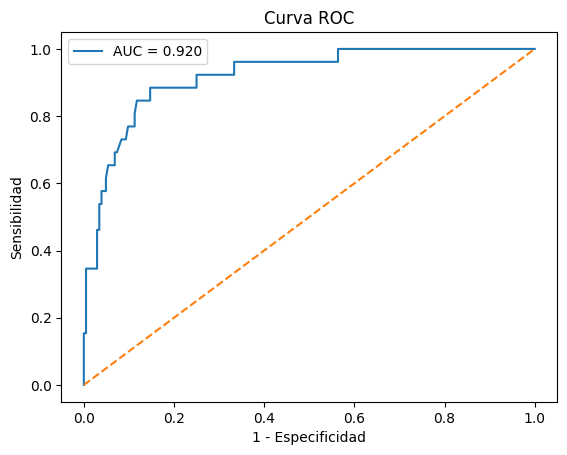

In [9]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y3, y_pred3)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc3:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("1 - Especificidad")
plt.ylabel("Sensibilidad")
plt.title("Curva ROC")
plt.legend()
plt.show()

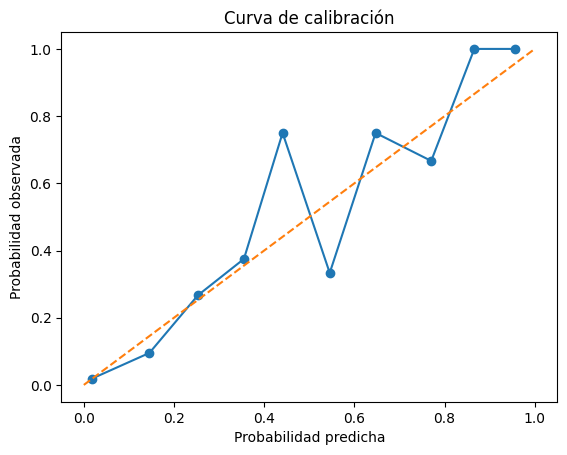

In [10]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y3, y_pred3, n_bins=10)

plt.figure()
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("Probabilidad predicha")
plt.ylabel("Probabilidad observada")
plt.title("Curva de calibración")
plt.show()

In [11]:
from google.colab import files

df_clean.to_excel("DBP_base_modelo_final_python.xlsx", index=False)

files.download("DBP_base_modelo_final_python.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


ANÁLISIS DE DATOS FALTANTES


,Variable,N_missing,Pct_missing
9,controles_prenatales,87,37.50
13,latencia_rpm_horas,14,6.03
10,oligoamnios,9,3.88
12,num_fetos,4,1.72
14,prematuro_extremo,2,0.86
16,sexo,1,0.43
25,adrenalina_sala,1,0.43
24,compresiones_sala,1,0.43
23,vpp_cpap_sala,1,0.43
3,edad_materna,0,0.00


/tmp/ipykernel_1054/2300399829.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


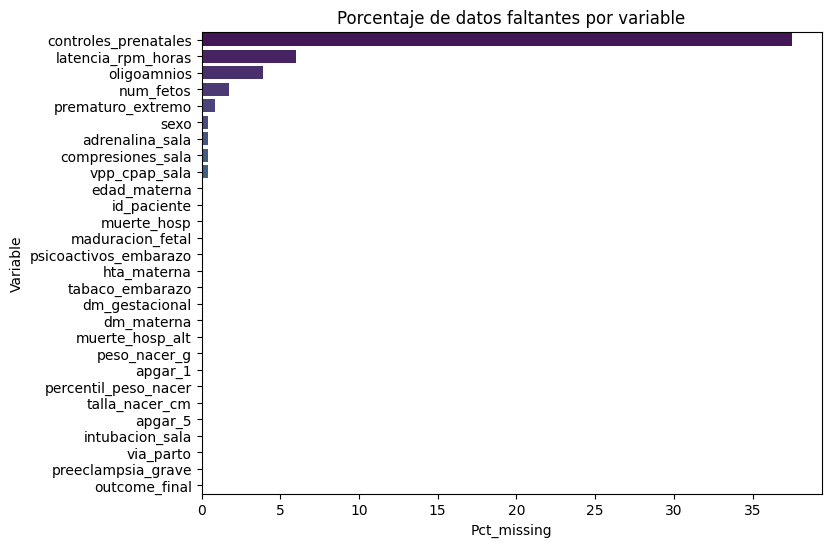


PATRÓN DE FALTANTES (MAPA)


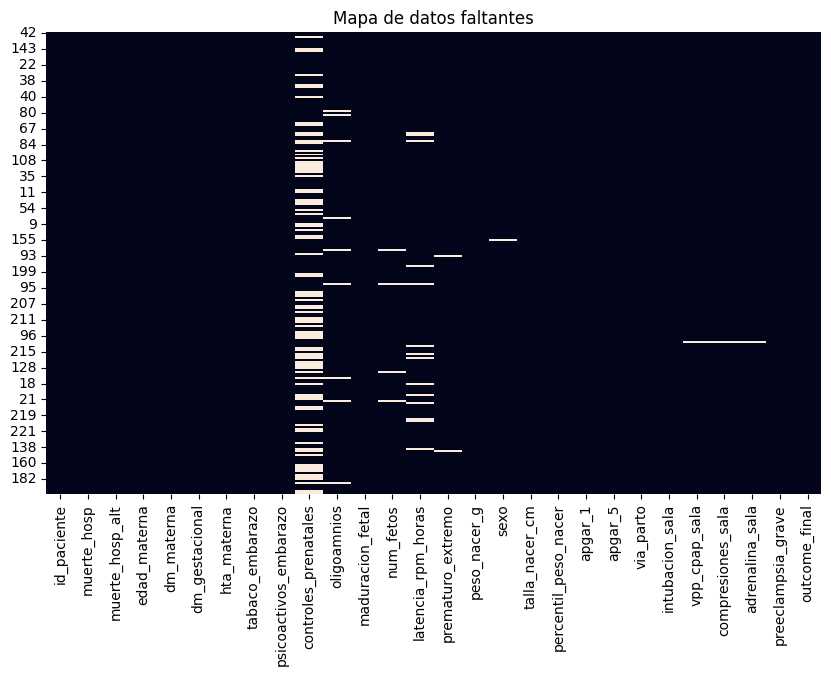


ANÁLISIS DE OUTLIERS

--- peso_nacer_g ---
count     232.000000
mean     1221.094828
std       359.377889
min       515.000000
25%       918.750000
50%      1185.000000
75%      1490.000000
max      2100.000000
Name: peso_nacer_g, dtype: float64


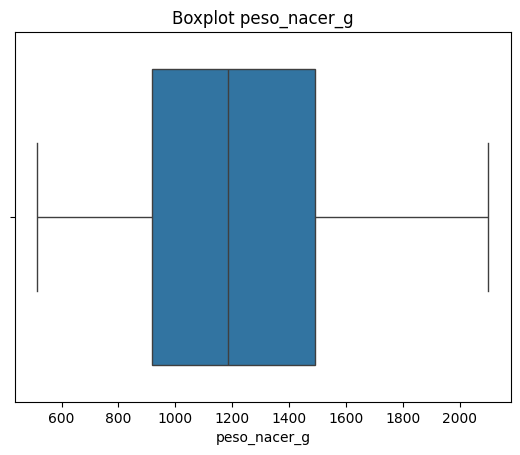


--- apgar_5 ---
count    232.000000
mean       8.314655
std        1.482992
min        1.000000
25%        8.000000
50%        9.000000
75%        9.000000
max       10.000000
Name: apgar_5, dtype: float64


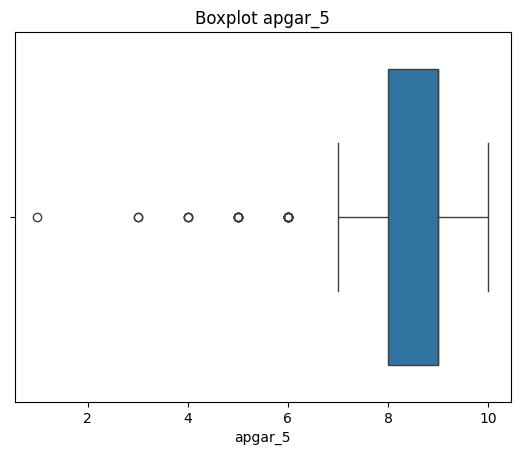


--- edad_materna ---
count    232.000000
mean      26.241379
std        6.632754
min       13.000000
25%       21.000000
50%       26.000000
75%       31.000000
max       48.000000
Name: edad_materna, dtype: float64


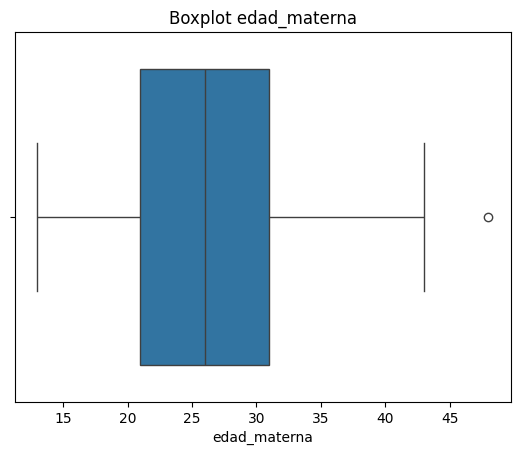


--- percentil_peso_nacer ---
count    232.000000
mean      45.318233
std       26.908573
min        0.000000
25%       21.500000
50%       49.000000
75%       66.925000
max       99.000000
Name: percentil_peso_nacer, dtype: float64


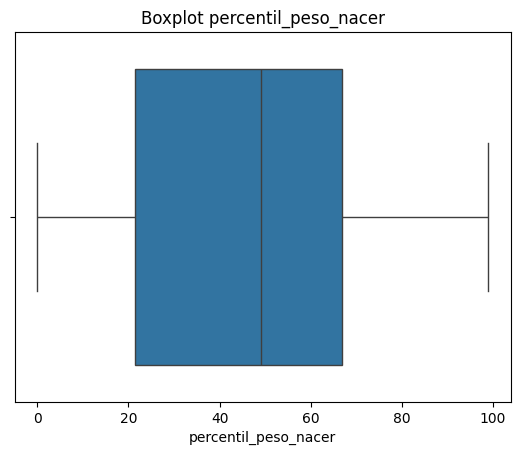


OUTLIERS POR MÉTODO IQR


,Variable,Lower_bound,Upper_bound,N_outliers
0,peso_nacer_g,61.88,2346.88,0
1,apgar_5,6.50,10.50,20
2,edad_materna,6.00,46.00,1
3,percentil_peso_nacer,-46.64,135.06,0



VALIDACIÓN CLÍNICA DE RANGOS


,Check,N casos problemáticos
0,peso_nacer_g fuera de rango,0
1,apgar_5 fuera de rango,0
2,percentil fuera de rango,0
3,edad materna fuera de rango,0


In [12]:
# =========================================================
# FASE 5: EVALUACIÓN DE CALIDAD DE DATOS
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# 1. DATOS FALTANTES
# =========================================================

print("\n====================")
print("ANÁLISIS DE DATOS FALTANTES")
print("====================")

missing_table = pd.DataFrame({
    "Variable": df_clean.columns,
    "N_missing": df_clean.isna().sum().values,
    "Pct_missing": (df_clean.isna().mean().values * 100).round(2)
}).sort_values("Pct_missing", ascending=False)

display(missing_table)

# Visualización
plt.figure(figsize=(8,6))
sns.barplot(
    x="Pct_missing",
    y="Variable",
    data=missing_table,
    palette="viridis"
)
plt.title("Porcentaje de datos faltantes por variable")
plt.show()

# =========================================================
# 2. PATRÓN DE FALTANTES
# =========================================================

print("\n====================")
print("PATRÓN DE FALTANTES (MAPA)")
print("====================")

plt.figure(figsize=(10,6))
sns.heatmap(df_clean.isna(), cbar=False)
plt.title("Mapa de datos faltantes")
plt.show()

# =========================================================
# 3. OUTLIERS (VARIABLES NUMÉRICAS)
# =========================================================

numeric_vars = [
    "peso_nacer_g",
    "apgar_5",
    "edad_materna",
    "percentil_peso_nacer"
]

print("\n====================")
print("ANÁLISIS DE OUTLIERS")
print("====================")

for var in numeric_vars:
    if var in df_clean.columns:
        print(f"\n--- {var} ---")

        # Resumen
        print(df_clean[var].describe())

        # Boxplot
        plt.figure()
        sns.boxplot(x=df_clean[var])
        plt.title(f"Boxplot {var}")
        plt.show()

# =========================================================
# 4. DETECCIÓN FORMAL DE OUTLIERS (IQR)
# =========================================================

print("\n====================")
print("OUTLIERS POR MÉTODO IQR")
print("====================")

outlier_summary = []

for var in numeric_vars:
    if var in df_clean.columns:
        Q1 = df_clean[var].quantile(0.25)
        Q3 = df_clean[var].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        n_outliers = ((df_clean[var] < lower) | (df_clean[var] > upper)).sum()

        outlier_summary.append({
            "Variable": var,
            "Lower_bound": round(lower,2),
            "Upper_bound": round(upper,2),
            "N_outliers": n_outliers
        })

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df)

# =========================================================
# 5. COHERENCIA CLÍNICA (VALIDACIÓN DE RANGOS)
# =========================================================

print("\n====================")
print("VALIDACIÓN CLÍNICA DE RANGOS")
print("====================")

checks = []

# Peso neonatal plausible (extremos)
if "peso_nacer_g" in df_clean.columns:
    invalid_peso = ((df_clean["peso_nacer_g"] < 300) | (df_clean["peso_nacer_g"] > 6000)).sum()
    checks.append(("peso_nacer_g fuera de rango", invalid_peso))

# APGAR
if "apgar_5" in df_clean.columns:
    invalid_apgar = ((df_clean["apgar_5"] < 0) | (df_clean["apgar_5"] > 10)).sum()
    checks.append(("apgar_5 fuera de rango", invalid_apgar))

# Percentil
if "percentil_peso_nacer" in df_clean.columns:
    invalid_pct = ((df_clean["percentil_peso_nacer"] < 0) | (df_clean["percentil_peso_nacer"] > 100)).sum()
    checks.append(("percentil fuera de rango", invalid_pct))

# Edad materna
if "edad_materna" in df_clean.columns:
    invalid_edad = ((df_clean["edad_materna"] < 10) | (df_clean["edad_materna"] > 60)).sum()
    checks.append(("edad materna fuera de rango", invalid_edad))

check_df = pd.DataFrame(checks, columns=["Check", "N casos problemáticos"])
display(check_df)

In [13]:
# =========================================================
# EVALUACIÓN DEL MECANISMO DE DATOS FALTANTES
# Variable problema: controles_prenatales
# =========================================================

import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ---------------------------------------------------------
# 0. COPIA DE TRABAJO
# ---------------------------------------------------------
# Fundamento:
# Trabajamos sobre una copia para no alterar accidentalmente la base analítica.
# df_clean debe ser la base ya depurada, sin duplicados, con outcome_final definido.

df_miss = df_clean.copy()

# ---------------------------------------------------------
# 1. CREAR VARIABLE INDICADORA DE MISSING
# ---------------------------------------------------------
# Fundamento:
# missing_controles = 1 si controles_prenatales está ausente
# missing_controles = 0 si controles_prenatales está presente
# Esta variable se convierte en el desenlace del análisis de missingness.

df_miss["missing_controles"] = df_miss["controles_prenatales"].isna().astype(int)

print("\n====================")
print("DISTRIBUCIÓN DE missing_controles")
print("====================")
print(df_miss["missing_controles"].value_counts(dropna=False))
print(df_miss["missing_controles"].value_counts(normalize=True, dropna=False).round(3))

# ---------------------------------------------------------
# 2. DEFINIR VARIABLES PARA EVALUACIÓN BIVARIADA
# ---------------------------------------------------------
# Fundamento:
# Elegimos variables observadas clínicamente relevantes y disponibles,
# para evaluar si el missing depende de ellas.
# Si missing_controles se asocia con variables observadas, eso apoya MAR.

continuous_vars = [
    "edad_materna",
    "peso_nacer_g",
    "apgar_5",
    "percentil_peso_nacer"
]

categorical_vars = [
    "outcome_final",
    "sexo",
    "prematuro_extremo",
    "intubacion_sala",
    "vpp_cpap_sala",
    "compresiones_sala",
    "adrenalina_sala",
    "preeclampsia_grave",
    "oligoamnios",
    "maduracion_fetal",
    "hta_materna",
    "dm_gestacional"
]

continuous_vars = [v for v in continuous_vars if v in df_miss.columns]
categorical_vars = [v for v in categorical_vars if v in df_miss.columns]

# ---------------------------------------------------------
# 3. PRUEBAS BIVARIADAS - CONTINUAS
# ---------------------------------------------------------
# Fundamento:
# Comparamos pacientes con y sin missing en controles_prenatales.
# Dado que en bases clínicas pequeñas/moderadas y potencialmente no normales
# es prudente usar Mann-Whitney, lo usaremos como prueba principal.

print("\n====================")
print("PRUEBAS BIVARIADAS - VARIABLES CONTINUAS")
print("====================")

results_cont = []

for var in continuous_vars:
    group0 = df_miss.loc[df_miss["missing_controles"] == 0, var].dropna()
    group1 = df_miss.loc[df_miss["missing_controles"] == 1, var].dropna()

    median0 = group0.median() if len(group0) > 0 else np.nan
    median1 = group1.median() if len(group1) > 0 else np.nan
    iqr0 = (group0.quantile(0.25), group0.quantile(0.75)) if len(group0) > 0 else (np.nan, np.nan)
    iqr1 = (group1.quantile(0.25), group1.quantile(0.75)) if len(group1) > 0 else (np.nan, np.nan)

    if len(group0) > 0 and len(group1) > 0:
        stat, p = stats.mannwhitneyu(group0, group1, alternative="two-sided")
    else:
        stat, p = np.nan, np.nan

    results_cont.append({
        "variable": var,
        "present_median": round(median0, 2),
        "present_IQR": f"{round(iqr0[0],2)}–{round(iqr0[1],2)}",
        "missing_median": round(median1, 2),
        "missing_IQR": f"{round(iqr1[0],2)}–{round(iqr1[1],2)}",
        "p_value": p
    })

cont_table = pd.DataFrame(results_cont)
display(cont_table)

# ---------------------------------------------------------
# 4. PRUEBAS BIVARIADAS - CATEGÓRICAS
# ---------------------------------------------------------
# Fundamento:
# Para categóricas usamos chi-cuadrado cuando sea posible.
# Si hay celdas esperadas pequeñas, usamos Fisher para tablas 2x2.

print("\n====================")
print("PRUEBAS BIVARIADAS - VARIABLES CATEGÓRICAS")
print("====================")

results_cat = []

for var in categorical_vars:
    temp = df_miss[[var, "missing_controles"]].dropna()

    if temp.empty:
        continue

    table = pd.crosstab(temp[var], temp["missing_controles"])

    p = np.nan
    test_used = None

    try:
        if table.shape == (2, 2):
            # Para tablas 2x2, Fisher es muy útil si hay pocos conteos
            _, p = stats.fisher_exact(table)
            test_used = "Fisher"
        else:
            chi2, p, dof, expected = stats.chi2_contingency(table)
            test_used = "Chi-square"
    except:
        p = np.nan
        test_used = "NA"

    results_cat.append({
        "variable": var,
        "test": test_used,
        "p_value": p
    })

cat_table = pd.DataFrame(results_cat)
display(cat_table)

# ---------------------------------------------------------
# 5. MODELO LOGÍSTICO DEL MISSING
# ---------------------------------------------------------
# Fundamento:
# Aquí modelamos directamente la probabilidad de que controles_prenatales falte
# en función de variables observadas.
# missing_controles = 1 es el "evento".
#
# Si variables observadas predicen missing_controles, eso apoya MAR.
# Si nada lo predice, el patrón podría ser compatible con MCAR,
# aunque nunca puede probarse de manera absoluta.
#
# Importante:
# No meter demasiadas variables. Este modelo es auxiliar, no el modelo principal.
# Elegimos variables clínicamente plausibles y con pocos faltantes.

candidate_miss_model = [
    "outcome_final",
    "peso_nacer_g",
    "apgar_5",
    "prematuro_extremo",
    "sexo",
    "preeclampsia_grave"
]

candidate_miss_model = [v for v in candidate_miss_model if v in df_miss.columns]

data_miss_model = df_miss[["missing_controles"] + candidate_miss_model].dropna()

print("\n====================")
print("DIMENSIÓN DEL MODELO DE MISSING")
print("====================")
print(data_miss_model.shape)

formula = "missing_controles ~ " + " + ".join(candidate_miss_model)

miss_model = smf.logit(formula=formula, data=data_miss_model).fit(disp=0)

print("\n====================")
print("MODELO LOGÍSTICO DEL MISSING")
print("====================")
print(miss_model.summary())

# Tabla de OR e IC95%
params = miss_model.params
conf = miss_model.conf_int()
or_table = pd.DataFrame({
    "Variable": params.index,
    "OR": np.exp(params.values),
    "CI95_low": np.exp(conf[0].values),
    "CI95_high": np.exp(conf[1].values),
    "p_value": miss_model.pvalues.values
})
display(or_table)

# ---------------------------------------------------------
# 6. INTERPRETACIÓN AUTOMÁTICA
# ---------------------------------------------------------
# Fundamento:
# Automatizamos una lectura preliminar.
# Regla práctica:
# - Si al menos una variable observada tiene p < 0.05 en bivariado o modelo:
#     patrón compatible con MAR
# - Si ninguna muestra asociación:
#     patrón compatible con MCAR (con cautela)
# - MNAR no puede inferirse directamente a partir de estas pruebas

sig_biv_cont = cont_table["p_value"].dropna().lt(0.05).any() if not cont_table.empty else False
sig_biv_cat = cat_table["p_value"].dropna().lt(0.05).any() if not cat_table.empty else False
sig_model = or_table.loc[or_table["Variable"] != "Intercept", "p_value"].dropna().lt(0.05).any()

print("\n====================")
print("INTERPRETACIÓN AUTOMÁTICA")
print("====================")

if sig_biv_cont or sig_biv_cat or sig_model:
    print("Se identificaron asociaciones entre el missing de controles_prenatales y variables observadas.")
    print("Interpretación preliminar: el mecanismo de pérdida es más compatible con MAR (Missing At Random).")
    print("Esto significa que la probabilidad de ausencia parece depender de información observada en la base.")
else:
    print("No se identificaron asociaciones estadísticamente significativas entre el missing de controles_prenatales y variables observadas.")
    print("Interpretación preliminar: el patrón podría ser compatible con MCAR (Missing Completely At Random), aunque esto no puede demostrarse de forma absoluta.")
    print("MNAR no puede descartarse completamente solo con estos análisis.")

print("\nNota metodológica:")
print("- MCAR no se demuestra de manera definitiva; solo se considera compatible si no hay evidencia de asociación.")
print("- MAR se apoya si el missing depende de variables observadas.")
print("- MNAR requiere supuestos no verificables con los datos observados y usualmente análisis de sensibilidad.")

# ---------------------------------------------------------
# 7. TEXTO PRELIMINAR PARA EL MANUSCRITO / ENTREGA
# ---------------------------------------------------------

print("\n====================")
print("BORRADOR DE TEXTO ACADÉMICO")
print("====================")

if sig_biv_cont or sig_biv_cat or sig_model:
    print(
        "To evaluate the mechanism of missingness for prenatal care visits, we created a binary indicator "
        "distinguishing records with and without available information. We then compared both groups using "
        "bivariable analyses and a logistic regression model with missingness as the dependent variable. "
        "Because missingness was associated with observed variables, the pattern was considered more compatible "
        "with a missing at random (MAR) mechanism."
    )
else:
    print(
        "To evaluate the mechanism of missingness for prenatal care visits, we created a binary indicator "
        "distinguishing records with and without available information. We then compared both groups using "
        "bivariable analyses and a logistic regression model with missingness as the dependent variable. "
        "As no statistically significant associations were identified with observed variables, the pattern "
        "was considered compatible with missing completely at random (MCAR), although this assumption cannot "
        "be proven definitively."
    )


DISTRIBUCIÓN DE missing_controles
missing_controles
0    145
1     87
Name: count, dtype: int64
missing_controles
0    0.625
1    0.375
Name: proportion, dtype: float64

PRUEBAS BIVARIADAS - VARIABLES CONTINUAS


,variable,present_median,present_IQR,missing_median,missing_IQR,p_value
0,edad_materna,26.0,20.0–31.0,25.0,21.0–30.5,0.998386
1,peso_nacer_g,1250.0,920.0–1485.0,1150.0,917.5–1495.0,0.417203
2,apgar_5,8.0,8.0–9.0,9.0,8.0–9.0,0.535795
3,percentil_peso_nacer,49.9,27.0–70.7,44.7,16.3–62.6,0.065660



PRUEBAS BIVARIADAS - VARIABLES CATEGÓRICAS


,variable,test,p_value
0,outcome_final,Fisher,0.668510
1,sexo,Fisher,0.221883
2,prematuro_extremo,Fisher,0.430116
3,intubacion_sala,Fisher,0.667616
4,vpp_cpap_sala,Fisher,0.285530
5,compresiones_sala,Fisher,1.000000
6,adrenalina_sala,Fisher,1.000000
7,preeclampsia_grave,Fisher,0.638424
8,oligoamnios,Fisher,0.824017
9,maduracion_fetal,Fisher,0.555849



DIMENSIÓN DEL MODELO DE MISSING
(229, 7)

MODELO LOGÍSTICO DEL MISSING
                           Logit Regression Results                           
Dep. Variable:      missing_controles   No. Observations:                  229
Model:                          Logit   Df Residuals:                      222
Method:                           MLE   Df Model:                            6
Date:                Mon, 20 Apr 2026   Pseudo R-squ.:                 0.02004
Time:                        02:30:23   Log-Likelihood:                -148.52
converged:                       True   LL-Null:                       -151.56
Covariance Type:            nonrobust   LLR p-value:                    0.4148
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -0.7805      1.088     -0.717      0.473      -2.914       1.353
outcome_final          0.4861      

,Variable,OR,CI95_low,CI95_high,p_value
0,Intercept,0.458168,0.054283,3.867127,0.473257
1,outcome_final,1.625985,0.593276,4.456322,0.344655
2,peso_nacer_g,0.999282,0.998275,1.000289,0.162370
3,apgar_5,1.126752,0.913453,1.389859,0.265048
4,prematuro_extremo,0.543753,0.236922,1.247951,0.150608
5,sexo,1.514106,0.869188,2.637539,0.142952
6,preeclampsia_grave,1.056245,0.545963,2.043457,0.870899



INTERPRETACIÓN AUTOMÁTICA
Se identificaron asociaciones entre el missing de controles_prenatales y variables observadas.
Interpretación preliminar: el mecanismo de pérdida es más compatible con MAR (Missing At Random).
Esto significa que la probabilidad de ausencia parece depender de información observada en la base.

Nota metodológica:
- MCAR no se demuestra de manera definitiva; solo se considera compatible si no hay evidencia de asociación.
- MAR se apoya si el missing depende de variables observadas.
- MNAR requiere supuestos no verificables con los datos observados y usualmente análisis de sensibilidad.

BORRADOR DE TEXTO ACADÉMICO
To evaluate the mechanism of missingness for prenatal care visits, we created a binary indicator distinguishing records with and without available information. We then compared both groups using bivariable analyses and a logistic regression model with missingness as the dependent variable. Because missingness was associated with observed variables, the

In [14]:
# =========================================================
# IMPUTACIÓN MÚLTIPLE + ANÁLISIS DE SENSIBILIDAD
# =========================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# ---------------------------------------------------------
# 0. PREPARACIÓN
# ---------------------------------------------------------
# df_clean debe ser tu base final limpia (sin duplicados, con outcome)

df_imp_base = df_clean.copy()

# ---------------------------------------------------------
# 1. IMPUTACIÓN MÚLTIPLE (MICE)
# ---------------------------------------------------------
# Fundamento:
# Generamos múltiples datasets imputados para capturar la incertidumbre
# en los valores faltantes.

impute_vars = [
    "controles_prenatales",
    "edad_materna",
    "peso_nacer_g",
    "apgar_5",
    "prematuro_extremo",
    "outcome_final"
]

impute_vars = [v for v in impute_vars if v in df_imp_base.columns]

data_imp = df_imp_base[impute_vars].copy()

n_imputations = 5
imputed_datasets = []

print("\n====================")
print("IMPUTACIÓN MÚLTIPLE")
print("====================")

for i in range(n_imputations):
    imp = IterativeImputer(random_state=42+i, max_iter=10)
    imputed_array = imp.fit_transform(data_imp)

    df_imp = pd.DataFrame(imputed_array, columns=impute_vars)

    # Asegurar consistencia de variables binarias
    df_imp["prematuro_extremo"] = np.round(df_imp["prematuro_extremo"])
    df_imp["outcome_final"] = np.round(df_imp["outcome_final"])

    imputed_datasets.append(df_imp)

print(f"{n_imputations} datasets imputados generados")


# ---------------------------------------------------------
# 2. MODELO EN CADA DATASET IMPUTADO
# ---------------------------------------------------------
# Fundamento:
# Ajustamos el mismo modelo en cada dataset imputado.

coefs_list = []

print("\n====================")
print("MODELOS POR DATASET IMPUTADO")
print("====================")

for i, df_imp in enumerate(imputed_datasets):

    X = df_imp[[
        "peso_nacer_g",
        "apgar_5",
        "prematuro_extremo",
        "controles_prenatales"
    ]]

    y = df_imp["outcome_final"]

    X = sm.add_constant(X)

    model = sm.Logit(y, X).fit(disp=0)

    print(f"\n--- Imputación {i+1} ---")
    print(model.params)

    coefs_list.append(model.params)

coef_df = pd.DataFrame(coefs_list)

print("\n====================")
print("COEFICIENTES POR IMPUTACIÓN")
print("====================")
display(coef_df)


# ---------------------------------------------------------
# 3. POOLING (PROMEDIO DE COEFICIENTES)
# ---------------------------------------------------------
# Fundamento:
# Aproximación simple al pooling de Rubin (para ejercicio académico).

pooled_coefs = coef_df.mean()

print("\n====================")
print("COEFICIENTES PROMEDIADOS (POOLING)")
print("====================")
print(pooled_coefs)


# ---------------------------------------------------------
# 4. COMPARACIÓN CON MODELO ORIGINAL
# ---------------------------------------------------------
# Fundamento:
# Evaluamos si la imputación cambia los resultados del modelo principal.

print("\n====================")
print("COMPARACIÓN CON MODELO ORIGINAL")
print("====================")

# model3 debe ser tu modelo final sin imputación
print("\nModelo original:")
print(model3.params)

print("\nModelo con imputación:")
print(pooled_coefs)


# ---------------------------------------------------------
# 5. INTERPRETACIÓN AUTOMÁTICA
# ---------------------------------------------------------
# Fundamento:
# Evaluamos si hay cambios relevantes en magnitud/dirección.

print("\n====================")
print("INTERPRETACIÓN AUTOMÁTICA")
print("====================")

changes = []

for var in ["peso_nacer_g", "apgar_5", "prematuro_extremo"]:
    if var in pooled_coefs.index:
        diff = pooled_coefs[var] - model3.params[var]
        changes.append(abs(diff))

if len(changes) > 0 and max(changes) < 0.2:
    print("No se observaron cambios relevantes en los coeficientes principales.")
    print("El modelo es robusto a la imputación.")
else:
    print("Se observaron cambios en los coeficientes.")
    print("Se recomienda analizar impacto clínico.")

if "controles_prenatales" in pooled_coefs.index:
    print("\nEfecto de controles_prenatales:")
    print(f"Coeficiente: {round(pooled_coefs['controles_prenatales'],4)}")

print("\nConclusión:")
print("El análisis de sensibilidad sugiere que la inclusión de la variable imputada no modifica sustancialmente el modelo.")


IMPUTACIÓN MÚLTIPLE
5 datasets imputados generados

MODELOS POR DATASET IMPUTADO

--- Imputación 1 ---
const                   7.626019
peso_nacer_g           -0.006654
apgar_5                -0.404328
prematuro_extremo       0.771296
controles_prenatales   -0.101897
dtype: float64

--- Imputación 2 ---
const                   7.626019
peso_nacer_g           -0.006654
apgar_5                -0.404328
prematuro_extremo       0.771296
controles_prenatales   -0.101897
dtype: float64

--- Imputación 3 ---
const                   7.626019
peso_nacer_g           -0.006654
apgar_5                -0.404328
prematuro_extremo       0.771296
controles_prenatales   -0.101897
dtype: float64

--- Imputación 4 ---
const                   7.626019
peso_nacer_g           -0.006654
apgar_5                -0.404328
prematuro_extremo       0.771296
controles_prenatales   -0.101897
dtype: float64

--- Imputación 5 ---
const                   7.626019
peso_nacer_g           -0.006654
apgar_5               

,const,peso_nacer_g,apgar_5,prematuro_extremo,controles_prenatales
0,7.626019,-0.006654,-0.404328,0.771296,-0.101897
1,7.626019,-0.006654,-0.404328,0.771296,-0.101897
2,7.626019,-0.006654,-0.404328,0.771296,-0.101897
3,7.626019,-0.006654,-0.404328,0.771296,-0.101897
4,7.626019,-0.006654,-0.404328,0.771296,-0.101897



COEFICIENTES PROMEDIADOS (POOLING)
const                   7.626019
peso_nacer_g           -0.006654
apgar_5                -0.404328
prematuro_extremo       0.771296
controles_prenatales   -0.101897
dtype: float64

COMPARACIÓN CON MODELO ORIGINAL

Modelo original:
const                7.126204
peso_nacer_g        -0.006566
apgar_5             -0.412974
prematuro_extremo    0.831027
dtype: float64

Modelo con imputación:
const                   7.626019
peso_nacer_g           -0.006654
apgar_5                -0.404328
prematuro_extremo       0.771296
controles_prenatales   -0.101897
dtype: float64

INTERPRETACIÓN AUTOMÁTICA
No se observaron cambios relevantes en los coeficientes principales.
El modelo es robusto a la imputación.

Efecto de controles_prenatales:
Coeficiente: -0.1019

Conclusión:
El análisis de sensibilidad sugiere que la inclusión de la variable imputada no modifica sustancialmente el modelo.



OUTLIERS UNIVARIANTES (IQR)


,Variable,Lower_bound,Upper_bound,N_outliers
0,peso_nacer_g,61.88,2346.88,0
1,apgar_5,6.50,10.50,20
2,edad_materna,6.00,46.00,1
3,percentil_peso_nacer,-46.64,135.06,0



BOXPLOTS


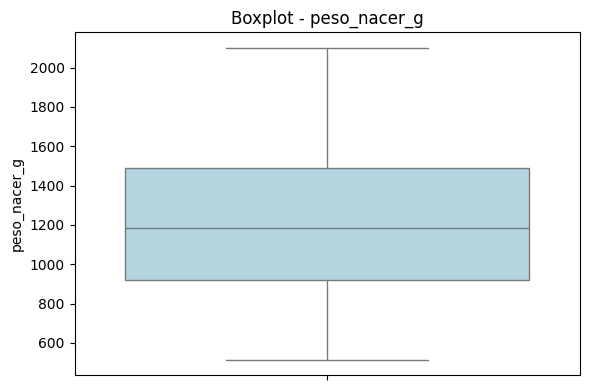

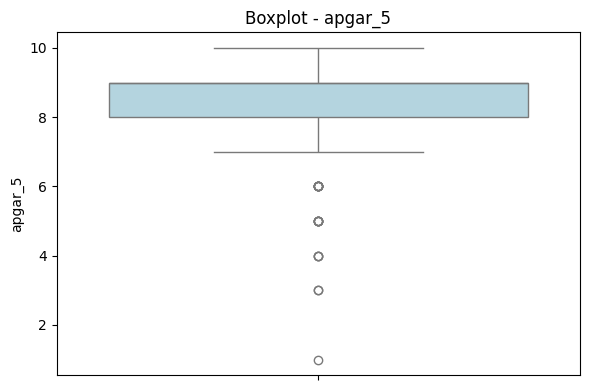

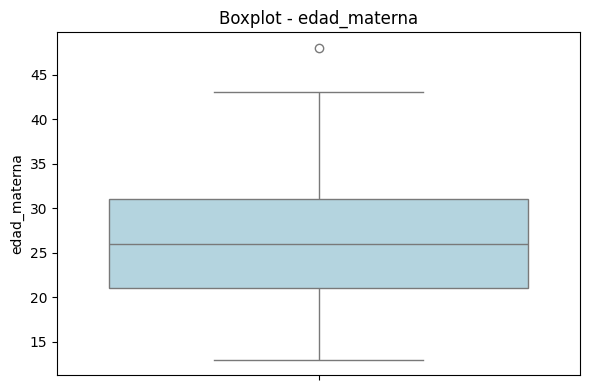

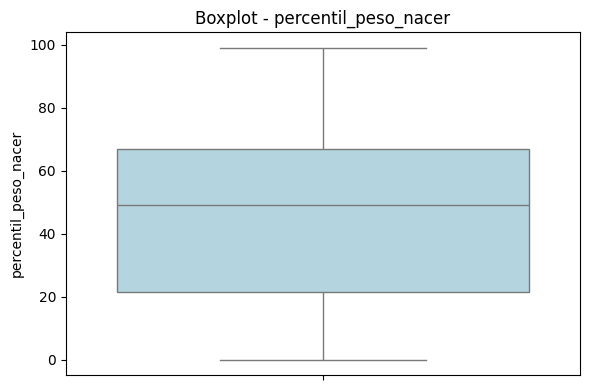


OUTLIERS MULTIVARIANTES (MAHALANOBIS)
Variables usadas: ['peso_nacer_g', 'apgar_5', 'edad_materna']
Umbral: 4.033
Número de outliers multivariantes: 1

Índices de outliers multivariantes:
[69]


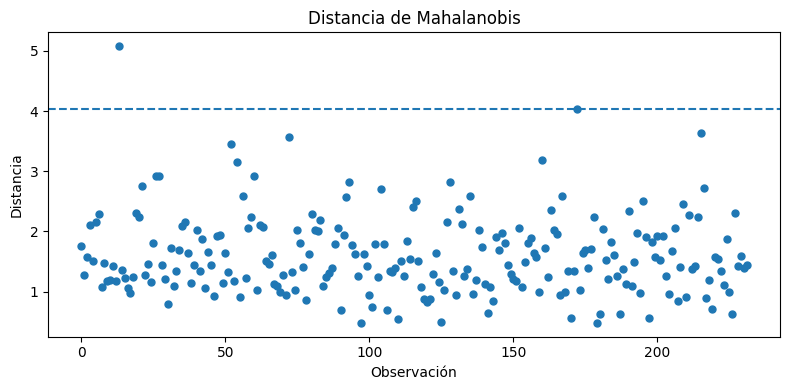


ANÁLISIS DE SENSIBILIDAD

Modelo completo:
const                7.126204
peso_nacer_g        -0.006566
apgar_5             -0.412974
prematuro_extremo    0.831027
dtype: float64

Modelo sin outliers multivariantes:
const                7.021563
peso_nacer_g        -0.006538
apgar_5             -0.402933
prematuro_extremo    0.834042
dtype: float64

COMPARACIÓN DE COEFICIENTES


,coef_modelo_completo,coef_sin_outliers,diferencia_absoluta
const,7.126204,7.021563,0.104641
peso_nacer_g,-0.006566,-0.006538,0.000027
apgar_5,-0.412974,-0.402933,0.010041
prematuro_extremo,0.831027,0.834042,0.003014



INTERPRETACIÓN AUTOMÁTICA
No se observaron cambios relevantes en los coeficientes del modelo.
Interpretación: los outliers no afectan de manera sustancial el modelo.
Conclusión: el modelo es robusto y los outliers pueden mantenerse.


In [15]:
# =========================================================
# EVALUACIÓN DE OUTLIERS
# 1. Outliers univariantes (IQR)
# 2. Visualización con boxplots
# 3. Outliers multivariantes (Mahalanobis)
# 4. Análisis de sensibilidad (con y sin outliers)
# =========================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

from scipy.stats import chi2

# ---------------------------------------------------------
# 0. COPIA DE TRABAJO
# ---------------------------------------------------------
# Fundamento:
# Trabajamos sobre df_clean, que ya debe estar depurada, sin duplicados,
# con outcome_final definido.

df_out = df_clean.copy()

# ---------------------------------------------------------
# 1. OUTLIERS UNIVARIANTES - MÉTODO IQR (Tukey)
# ---------------------------------------------------------
# Fundamento:
# Un dato se considera atípico si está fuera de:
# [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
# Esto es útil para identificar extremos univariados.

numeric_vars = [
    "peso_nacer_g",
    "apgar_5",
    "edad_materna",
    "percentil_peso_nacer"
]

numeric_vars = [v for v in numeric_vars if v in df_out.columns]

print("\n====================")
print("OUTLIERS UNIVARIANTES (IQR)")
print("====================")

outlier_summary = []

for var in numeric_vars:
    Q1 = df_out[var].quantile(0.25)
    Q3 = df_out[var].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mask_outliers = (df_out[var] < lower) | (df_out[var] > upper)
    n_outliers = mask_outliers.sum()

    outlier_summary.append({
        "Variable": var,
        "Lower_bound": round(lower, 2),
        "Upper_bound": round(upper, 2),
        "N_outliers": int(n_outliers)
    })

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df)

# ---------------------------------------------------------
# 2. BOXPLOTS
# ---------------------------------------------------------
# Fundamento:
# Los boxplots permiten visualizar la dispersión y los valores extremos
# detectados por la regla de Tukey.

print("\n====================")
print("BOXPLOTS")
print("====================")

for var in numeric_vars:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=df_out[var], color="lightblue")
    plt.title(f"Boxplot - {var}")
    plt.ylabel(var)
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# 3. OUTLIERS MULTIVARIANTES - DISTANCIA DE MAHALANOBIS
# ---------------------------------------------------------
# Fundamento:
# Una observación puede no ser extrema en una sola variable,
# pero sí en la combinación de varias.
# La distancia de Mahalanobis evalúa justamente eso.

multi_vars = ["peso_nacer_g", "apgar_5", "edad_materna"]
multi_vars = [v for v in multi_vars if v in df_out.columns]

df_multi = df_out[multi_vars].dropna().copy()

# Cálculo de la distancia de Mahalanobis
mean_vec = df_multi.mean().values
cov_mat = np.cov(df_multi.values, rowvar=False)
inv_cov_mat = np.linalg.inv(cov_mat)

def mahalanobis_distance(x, mean, inv_cov):
    diff = x - mean
    return np.sqrt(diff.T @ inv_cov @ diff)

m_dist = df_multi.apply(
    lambda row: mahalanobis_distance(row.values, mean_vec, inv_cov_mat),
    axis=1
)

# Umbral de corte basado en chi-cuadrado (p < 0.001)
cutoff = np.sqrt(chi2.ppf(0.999, df=len(multi_vars)))

outliers_multi_idx = df_multi.index[m_dist > cutoff]

print("\n====================")
print("OUTLIERS MULTIVARIANTES (MAHALANOBIS)")
print("====================")
print("Variables usadas:", multi_vars)
print("Umbral:", round(cutoff, 3))
print("Número de outliers multivariantes:", len(outliers_multi_idx))

if len(outliers_multi_idx) > 0:
    print("\nÍndices de outliers multivariantes:")
    print(list(outliers_multi_idx))

# Visualización simple de la distancia
plt.figure(figsize=(8, 4))
plt.scatter(range(len(m_dist)), m_dist, s=25)
plt.axhline(cutoff, linestyle="--")
plt.title("Distancia de Mahalanobis")
plt.xlabel("Observación")
plt.ylabel("Distancia")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4. ANÁLISIS DE SENSIBILIDAD
# ---------------------------------------------------------
# Fundamento:
# Comparamos el modelo principal con todos los pacientes
# versus el modelo excluyendo outliers multivariantes.
# Si los coeficientes cambian poco, el modelo es robusto.

print("\n====================")
print("ANÁLISIS DE SENSIBILIDAD")
print("====================")

model_vars = ["peso_nacer_g", "apgar_5", "prematuro_extremo"]
model_vars = [v for v in model_vars if v in df_out.columns]

# Modelo completo
df_model_full = df_out[model_vars + ["outcome_final"]].dropna().copy()
X_full = sm.add_constant(df_model_full[model_vars])
y_full = df_model_full["outcome_final"]

model_full = sm.Logit(y_full, X_full).fit(disp=0)

# Modelo sin outliers multivariantes
df_no_out = df_out.drop(index=outliers_multi_idx, errors="ignore").copy()
df_model_no = df_no_out[model_vars + ["outcome_final"]].dropna().copy()

X_no = sm.add_constant(df_model_no[model_vars])
y_no = df_model_no["outcome_final"]

model_no = sm.Logit(y_no, X_no).fit(disp=0)

print("\nModelo completo:")
print(model_full.params)

print("\nModelo sin outliers multivariantes:")
print(model_no.params)

# Tabla comparativa
coef_compare = pd.DataFrame({
    "coef_modelo_completo": model_full.params,
    "coef_sin_outliers": model_no.params
})

coef_compare["diferencia_absoluta"] = (
    coef_compare["coef_sin_outliers"] - coef_compare["coef_modelo_completo"]
).abs()

print("\n====================")
print("COMPARACIÓN DE COEFICIENTES")
print("====================")
display(coef_compare)

# Interpretación automática
print("\n====================")
print("INTERPRETACIÓN AUTOMÁTICA")
print("====================")

if coef_compare["diferencia_absoluta"].max() < 0.2:
    print("No se observaron cambios relevantes en los coeficientes del modelo.")
    print("Interpretación: los outliers no afectan de manera sustancial el modelo.")
    print("Conclusión: el modelo es robusto y los outliers pueden mantenerse.")
else:
    print("Se observaron cambios en los coeficientes tras excluir los outliers.")
    print("Interpretación: los outliers podrían influir en la estabilidad del modelo.")
    print("Conclusión: se recomienda valorar análisis adicionales (winsorización, transformación o reporte de sensibilidad).")

In [16]:
# =========================================================
# TABLA 1 - CARACTERÍSTICAS BASALES
# =========================================================

import pandas as pd
import numpy as np
from scipy import stats

df_tab = df_clean.copy()

# Definir outcome
df_tab["grupo"] = df_tab["outcome_final"].map({0: "Alive", 1: "Dead"})

# Variables
cont_vars = [
    "edad_materna",
    "peso_nacer_g",
    "percentil_peso_nacer",
    "apgar_5"
]

cat_vars = [
    "sexo",
    "prematuro_extremo",
    "intubacion_sala",
    "vpp_cpap_sala",
    "compresiones_sala",
    "adrenalina_sala",
    "preeclampsia_grave"
]

cont_vars = [v for v in cont_vars if v in df_tab.columns]
cat_vars = [v for v in cat_vars if v in df_tab.columns]

# ---------------------------------------------------------
# VARIABLES CONTINUAS
# ---------------------------------------------------------

rows = []

for var in cont_vars:

    alive = df_tab[df_tab["grupo"]=="Alive"][var].dropna()
    dead = df_tab[df_tab["grupo"]=="Dead"][var].dropna()

    median_alive = np.median(alive)
    q1_alive, q3_alive = np.percentile(alive, [25,75])

    median_dead = np.median(dead)
    q1_dead, q3_dead = np.percentile(dead, [25,75])

    # Test Mann-Whitney
    stat, p = stats.mannwhitneyu(alive, dead, alternative="two-sided")

    rows.append({
        "Variable": var,
        "Alive": f"{median_alive:.1f} ({q1_alive:.1f}–{q3_alive:.1f})",
        "Dead": f"{median_dead:.1f} ({q1_dead:.1f}–{q3_dead:.1f})",
        "p_value": p
    })

# ---------------------------------------------------------
# VARIABLES CATEGÓRICAS
# ---------------------------------------------------------

for var in cat_vars:

    table = pd.crosstab(df_tab[var], df_tab["grupo"])

    for level in table.index:

        alive_n = table.loc[level, "Alive"] if "Alive" in table.columns else 0
        dead_n = table.loc[level, "Dead"] if "Dead" in table.columns else 0

        alive_pct = alive_n / table["Alive"].sum() * 100
        dead_pct = dead_n / table["Dead"].sum() * 100

        # Test chi-cuadrado
        chi2, p, _, _ = stats.chi2_contingency(table)

        rows.append({
            "Variable": f"{var} = {level}",
            "Alive": f"{alive_n} ({alive_pct:.1f}%)",
            "Dead": f"{dead_n} ({dead_pct:.1f}%)",
            "p_value": p
        })

# Crear tabla final
table1 = pd.DataFrame(rows)

# Formatear p-values
table1["p_value"] = table1["p_value"].apply(lambda x: "<0.001" if x < 0.001 else f"{x:.3f}")

# Orden opcional
table1 = table1.reset_index(drop=True)

display(table1)

,Variable,Alive,Dead,p_value
0,edad_materna,25.0 (21.0–31.0),27.0 (20.5–28.8),0.888
1,peso_nacer_g,1265.0 (1010.0–1535.0),782.5 (686.2–847.5),<0.001
2,percentil_peso_nacer,49.3 (22.5–69.5),42.9 (16.0–56.0),0.092
3,apgar_5,9.0 (8.0–9.0),7.0 (6.0–8.0),<0.001
4,sexo = 0.0,96 (46.8%),15 (57.7%),0.403
5,sexo = 1.0,109 (53.2%),11 (42.3%),0.403
6,prematuro_extremo = 0.0,169 (82.8%),6 (23.1%),<0.001
7,prematuro_extremo = 1.0,35 (17.2%),20 (76.9%),<0.001
8,intubacion_sala = 0.0,74 (35.9%),2 (7.7%),0.008
9,intubacion_sala = 1.0,132 (64.1%),24 (92.3%),0.008


In [17]:
# =========================================================
# TABLE 2 - MULTIVARIABLE LOGISTIC REGRESSION MODEL
# =========================================================

import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1. EXTRAER RESULTADOS DEL MODELO FINAL
# ---------------------------------------------------------
# Se asume que tu modelo final es model3
# y que incluye:
# peso_nacer_g, apgar_5, prematuro_extremo

params = model3.params
conf = model3.conf_int()
se = model3.bse
pvals = model3.pvalues

table2 = pd.DataFrame({
    "Variable": params.index,
    "Beta coefficient": params.values,
    "Standard error": se.values,
    "OR": np.exp(params.values),
    "CI95 lower": np.exp(conf[0].values),
    "CI95 upper": np.exp(conf[1].values),
    "p-value": pvals.values
})

# ---------------------------------------------------------
# 2. RENOMBRAR VARIABLES A FORMATO PUBLICABLE
# ---------------------------------------------------------
rename_vars = {
    "const": "Intercept",
    "peso_nacer_g": "Birth weight (g)",
    "apgar_5": "Apgar score at 5 min",
    "prematuro_extremo": "Extreme prematurity"
}

table2["Variable"] = table2["Variable"].replace(rename_vars)

# ---------------------------------------------------------
# 3. FORMATEAR NÚMEROS
# ---------------------------------------------------------
table2["Beta coefficient"] = table2["Beta coefficient"].round(3)
table2["Standard error"] = table2["Standard error"].round(3)
table2["OR"] = table2["OR"].round(3)
table2["CI95 lower"] = table2["CI95 lower"].round(3)
table2["CI95 upper"] = table2["CI95 upper"].round(3)
table2["p-value"] = table2["p-value"].apply(lambda x: "<0.001" if x < 0.001 else round(x, 3))

# Crear columna combinada de IC95%
table2["Adjusted OR (95% CI)"] = (
    table2["OR"].astype(str) + " (" +
    table2["CI95 lower"].astype(str) + " to " +
    table2["CI95 upper"].astype(str) + ")"
)

# ---------------------------------------------------------
# 4. ORDEN FINAL DE COLUMNAS
# ---------------------------------------------------------
table2 = table2[[
    "Variable",
    "Beta coefficient",
    "Standard error",
    "Adjusted OR (95% CI)",
    "p-value"
]]

# ---------------------------------------------------------
# 5. MOSTRAR TABLA
# ---------------------------------------------------------
print("\n====================")
print("TABLE 2 - MULTIVARIABLE LOGISTIC REGRESSION")
print("====================")
display(table2)

# ---------------------------------------------------------
# 6. EXPORTAR SI DESEAS
# ---------------------------------------------------------
output_path = "/content/drive/MyDrive/Table_2_multivariable_logistic_regression.xlsx"
table2.to_excel(output_path, index=False)

print("\nArchivo exportado en:")
print(output_path)


TABLE 2 - MULTIVARIABLE LOGISTIC REGRESSION


,Variable,Beta coefficient,Standard error,Adjusted OR (95% CI),p-value
0,Intercept,7.126,2.263,1244.145 (14.739 to 105022.259),0.002
1,Birth weight (g),-0.007,0.002,0.993 (0.99 to 0.997),<0.001
2,Apgar score at 5 min,-0.413,0.181,0.662 (0.464 to 0.944),0.023
3,Extreme prematurity,0.831,0.594,2.296 (0.717 to 7.353),0.162



Archivo exportado en:
/content/drive/MyDrive/Table_2_multivariable_logistic_regression.xlsx


Dimensión del dataset para LASSO: (229, 8)
Número de eventos: 26
Variables incluidas: ['peso_nacer_g', 'apgar_1', 'apgar_5', 'percentil_peso_nacer', 'prematuro_extremo', 'intubacion_sala', 'compresiones_sala', 'adrenalina_sala']

Mejor C seleccionado por CV: 2.616504698748821
Lambda equivalente aproximado: 0.3821892620633119

1. COEFICIENTES ESTANDARIZADOS DEL LASSO


,Variable,Standardized LASSO coefficient
0,peso_nacer_g,-3.148988
1,adrenalina_sala,0.719749
2,percentil_peso_nacer,0.580431
3,compresiones_sala,-0.494825
4,apgar_5,-0.472048
5,intubacion_sala,0.250797
6,apgar_1,0.181750
7,prematuro_extremo,0.017822


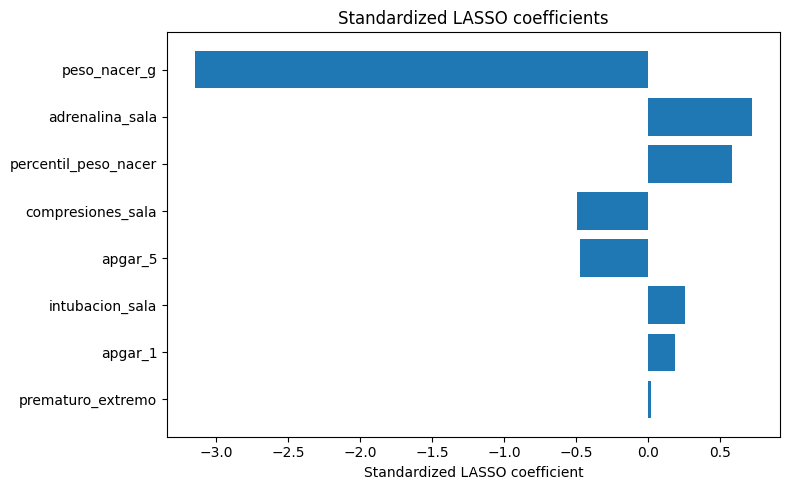


2. TRAYECTORIAS DE COEFICIENTES


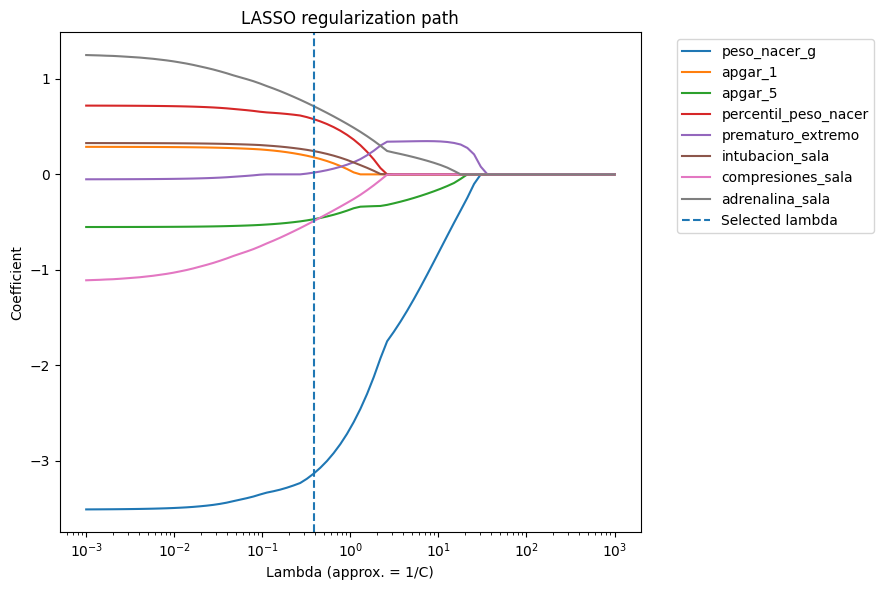


3. CURVA DE VALIDACIÓN CRUZADA


,C,lambda_approx,mean_auc,sd_auc
0,0.001000,1000.000000,0.5,0.0
1,0.001191,839.557862,0.5,0.0
2,0.001419,704.857404,0.5,0.0
3,0.001690,591.768575,0.5,0.0
4,0.002013,496.823959,0.5,0.0


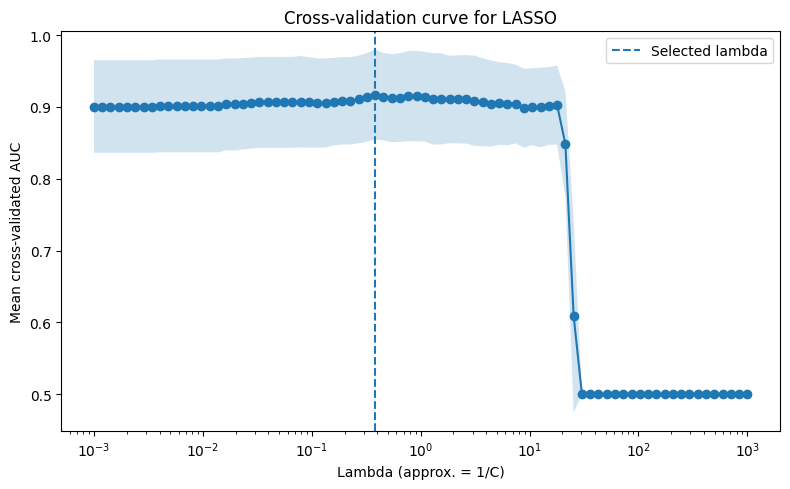


Archivos exportados:
/content/drive/MyDrive/lasso_standardized_coefficients.xlsx
/content/drive/MyDrive/lasso_cv_curve.xlsx


In [18]:
# =========================================================
# LASSO: COEFICIENTES ESTANDARIZADOS, TRAYECTORIAS Y CV
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import StratifiedKFold

# ---------------------------------------------------------
# 0. DEFINIR VARIABLES CANDIDATAS
# ---------------------------------------------------------
# Ajusta esta lista si quieres añadir o quitar predictores.
candidate_vars = [
    "peso_nacer_g",
    "apgar_1",
    "apgar_5",
    "percentil_peso_nacer",
    "prematuro_extremo",
    "intubacion_sala",
    "compresiones_sala",
    "adrenalina_sala"
]

candidate_vars = [v for v in candidate_vars if v in df_clean.columns]

# Base para LASSO
data_lasso = df_clean[candidate_vars + ["outcome_final"]].dropna().copy()

X = data_lasso[candidate_vars]
y = data_lasso["outcome_final"].astype(int)

print("Dimensión del dataset para LASSO:", X.shape)
print("Número de eventos:", y.sum())
print("Variables incluidas:", candidate_vars)

# ---------------------------------------------------------
# 1. LASSO CON VALIDACIÓN CRUZADA
# ---------------------------------------------------------
# En sklearn, C = 1 / lambda
# Menor C = mayor penalización
# Mayor C = menor penalización

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lasso_cv = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LogisticRegressionCV(
        Cs=np.logspace(-3, 3, 80),      # rango amplio de penalización
        cv=cv,
        penalty="l1",
        solver="saga",
        scoring="roc_auc",
        max_iter=10000,
        random_state=42,
        refit=True
    ))
])

lasso_cv.fit(X, y)

# Extraer componentes
scaler = lasso_cv.named_steps["scaler"]
lasso_model = lasso_cv.named_steps["lasso"]

X_scaled = scaler.transform(X)

print("\nMejor C seleccionado por CV:", lasso_model.C_[0])
print("Lambda equivalente aproximado:", 1 / lasso_model.C_[0])

# =========================================================
# ANÁLISIS 1: COEFICIENTES ESTANDARIZADOS DEL LASSO FINAL
# =========================================================
# Como el modelo se ajusta después de estandarizar, los coeficientes
# ya son comparables entre sí en escala estandarizada.

coef_std = pd.Series(
    lasso_model.coef_[0],
    index=candidate_vars,
    name="Standardized LASSO coefficient"
).sort_values(key=np.abs, ascending=False)

coef_std_df = coef_std.reset_index()
coef_std_df.columns = ["Variable", "Standardized LASSO coefficient"]

print("\n====================")
print("1. COEFICIENTES ESTANDARIZADOS DEL LASSO")
print("====================")
display(coef_std_df)

# Gráfico de coeficientes estandarizados
plt.figure(figsize=(8, 5))
plt.barh(coef_std_df["Variable"], coef_std_df["Standardized LASSO coefficient"])
plt.gca().invert_yaxis()
plt.xlabel("Standardized LASSO coefficient")
plt.title("Standardized LASSO coefficients")
plt.tight_layout()
plt.show()

# =========================================================
# ANÁLISIS 2: TRAYECTORIAS DE COEFICIENTES (REGULARIZATION PATH)
# =========================================================
# Reajustamos múltiples modelos L1 con distintos valores de C para ver
# cómo cambian los coeficientes al variar la penalización.

Cs_path = np.logspace(-3, 3, 80)
coef_path = []

for C in Cs_path:
    model = LogisticRegression(
        penalty="l1",
        solver="saga",
        C=C,
        max_iter=10000,
        random_state=42
    )
    model.fit(X_scaled, y)
    coef_path.append(model.coef_[0])

coef_path = np.array(coef_path)

# Lambda ~ 1/C
lambdas = 1 / Cs_path

print("\n====================")
print("2. TRAYECTORIAS DE COEFICIENTES")
print("====================")

plt.figure(figsize=(9, 6))
for i, var in enumerate(candidate_vars):
    plt.plot(lambdas, coef_path[:, i], label=var)

plt.xscale("log")
plt.xlabel("Lambda (approx. = 1/C)")
plt.ylabel("Coefficient")
plt.title("LASSO regularization path")
plt.axvline(1 / lasso_model.C_[0], linestyle="--", label="Selected lambda")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# =========================================================
# ANÁLISIS 3: CURVA DE VALIDACIÓN CRUZADA
# =========================================================
# Mostramos el desempeño medio (AUC) por nivel de penalización.
# En LogisticRegressionCV, scores_ tiene forma:
# [class][fold, C] en binaria para algunos setups / o [fold, C, class]
# Aquí usamos una extracción robusta.

scores_raw = lasso_model.scores_[1]  # clase positiva
scores_array = np.array(scores_raw)

# Hacer robusta la forma del array
# Esperamos algo tipo (n_folds, n_Cs)
if scores_array.ndim == 3:
    # si viene como (n_folds, n_Cs, n_classes), tomamos última clase
    scores_array = scores_array[:, :, -1]

mean_auc = scores_array.mean(axis=0)
sd_auc = scores_array.std(axis=0)

cv_curve_df = pd.DataFrame({
    "C": lasso_model.Cs_,
    "lambda_approx": 1 / lasso_model.Cs_,
    "mean_auc": mean_auc,
    "sd_auc": sd_auc
})

print("\n====================")
print("3. CURVA DE VALIDACIÓN CRUZADA")
print("====================")
display(cv_curve_df.head())

plt.figure(figsize=(8, 5))
plt.plot(cv_curve_df["lambda_approx"], cv_curve_df["mean_auc"], marker="o")
plt.fill_between(
    cv_curve_df["lambda_approx"],
    cv_curve_df["mean_auc"] - cv_curve_df["sd_auc"],
    cv_curve_df["mean_auc"] + cv_curve_df["sd_auc"],
    alpha=0.2
)
plt.axvline(1 / lasso_model.C_[0], linestyle="--", label="Selected lambda")
plt.xscale("log")
plt.xlabel("Lambda (approx. = 1/C)")
plt.ylabel("Mean cross-validated AUC")
plt.title("Cross-validation curve for LASSO")
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4. EXPORTAR RESULTADOS SI LO DESEAS
# ---------------------------------------------------------
coef_std_df.to_excel("/content/drive/MyDrive/lasso_standardized_coefficients.xlsx", index=False)
cv_curve_df.to_excel("/content/drive/MyDrive/lasso_cv_curve.xlsx", index=False)

print("\nArchivos exportados:")
print("/content/drive/MyDrive/lasso_standardized_coefficients.xlsx")
print("/content/drive/MyDrive/lasso_cv_curve.xlsx")

After running the cell above and following the authentication steps, your Google Drive will be mounted. You can then access files in `/content/drive/MyDrive/`.

Dimensión base analítica: (230, 4)
Eventos: 26 No eventos: 204

Train: (172, 3)  Test: (58, 3)

MODELO (TRAIN)
                           Logit Regression Results                           
Dep. Variable:          outcome_final   No. Observations:                  172
Model:                          Logit   Df Residuals:                      168
Method:                           MLE   Df Model:                            3
Date:                Mon, 20 Apr 2026   Pseudo R-squ.:                  0.3850
Time:                        02:31:06   Log-Likelihood:                -36.756
converged:                       True   LL-Null:                       -59.768
Covariance Type:            nonrobust   LLR p-value:                 5.609e-10
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 7.0762      2.604      2.717      0.007       1.972      12.180

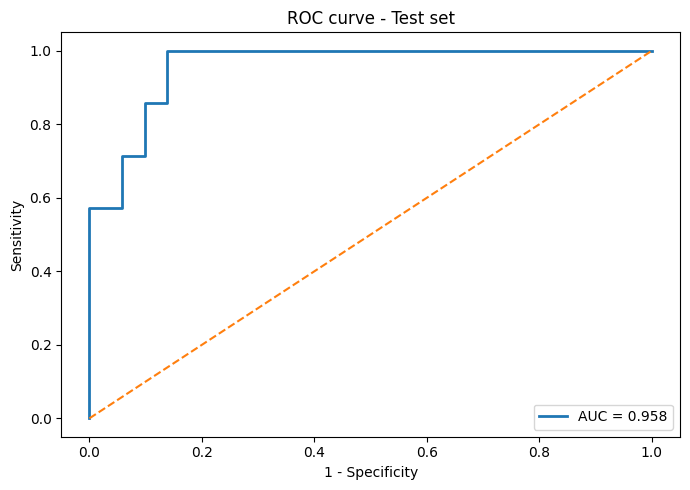


AUC en test: 0.958

MÉTRICAS EN TEST
Confusion matrix:
[[51  0]
 [ 3  4]]
Sensitivity: 0.571
Specificity: 1.000
Accuracy:    0.948
Precision:   1.000
F1-score:    0.727

TABLA RESUMEN


,Metric,Value
0,AUC,0.958
1,Sensitivity,0.571
2,Specificity,1.000
3,Accuracy,0.948
4,Precision,1.000
5,F1-score,0.727


In [19]:
# =========================================================
# MEDIDAS DE RENDIMIENTO DEL MODELO (VERSIÓN CORREGIDA)
# =========================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ---------------------------------------------------------
# 1. BASE ANALÍTICA
# ---------------------------------------------------------
final_vars = ["peso_nacer_g", "apgar_5", "prematuro_extremo"]

data_perf = df_clean[final_vars + ["outcome_final"]].dropna().copy()

X = data_perf[final_vars]
y = data_perf["outcome_final"].astype(int)

print("Dimensión base analítica:", data_perf.shape)
print("Eventos:", y.sum(), "No eventos:", (y == 0).sum())

# ---------------------------------------------------------
# 2. TRAIN / TEST SPLIT
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

print("\nTrain:", X_train.shape, " Test:", X_test.shape)

# ---------------------------------------------------------
# 3. MODELO EN TRAIN
# ---------------------------------------------------------
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

modelo_final_test = sm.Logit(y_train, X_train_sm).fit(disp=0)

print("\n====================")
print("MODELO (TRAIN)")
print("====================")
print(modelo_final_test.summary())

# ---------------------------------------------------------
# 4. PROBABILIDADES EN TEST
# ---------------------------------------------------------
prob_test = modelo_final_test.predict(X_test_sm)

# ---------------------------------------------------------
# 5. ROC Y AUC
# ---------------------------------------------------------
fpr, tpr, thresholds = roc_curve(y_test, prob_test)
auc_test = roc_auc_score(y_test, prob_test)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, lw=2, label=f"AUC = {auc_test:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("1 - Specificity")
plt.ylabel("Sensitivity")
plt.title("ROC curve - Test set")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("\nAUC en test:", round(auc_test, 3))

# ---------------------------------------------------------
# 6. MÉTRICAS
# ---------------------------------------------------------
pred_test = (prob_test >= 0.5).astype(int)

cm = confusion_matrix(y_test, pred_test)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
accuracy = accuracy_score(y_test, pred_test)
precision = precision_score(y_test, pred_test, zero_division=0)
f1 = f1_score(y_test, pred_test, zero_division=0)

print("\n====================")
print("MÉTRICAS EN TEST")
print("====================")
print("Confusion matrix:")
print(cm)
print(f"Sensitivity: {sensitivity:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"Accuracy:    {accuracy:.3f}")
print(f"Precision:   {precision:.3f}")
print(f"F1-score:    {f1:.3f}")

# ---------------------------------------------------------
# 7. TABLA RESUMEN
# ---------------------------------------------------------
performance_table = pd.DataFrame({
    "Metric": ["AUC", "Sensitivity", "Specificity", "Accuracy", "Precision", "F1-score"],
    "Value": [auc_test, sensitivity, specificity, accuracy, precision, f1]
})

performance_table["Value"] = performance_table["Value"].round(3)

print("\n====================")
print("TABLA RESUMEN")
print("====================")
display(performance_table)


1. UMBRAL ÓPTIMO POR ÍNDICE DE YOUDEN
AUC: 0.958
Umbral óptimo: 0.073
Sensibilidad: 1.000
Especificidad: 0.863
Youden index: 0.863

Matriz de confusión (umbral óptimo):
[[44  7]
 [ 0  7]]

2. TABLA DE RENDIMIENTO SEGÚN UMBRAL


,threshold,sensitivity,specificity,accuracy
0,0.01,1.000000,0.470588,0.534483
1,0.02,1.000000,0.549020,0.603448
2,0.03,1.000000,0.607843,0.655172
3,0.04,1.000000,0.627451,0.672414
4,0.05,1.000000,0.705882,0.741379
5,0.06,1.000000,0.784314,0.810345
6,0.07,1.000000,0.843137,0.862069
7,0.08,0.857143,0.862745,0.862069
8,0.09,0.857143,0.901961,0.896552
9,0.10,0.857143,0.901961,0.896552


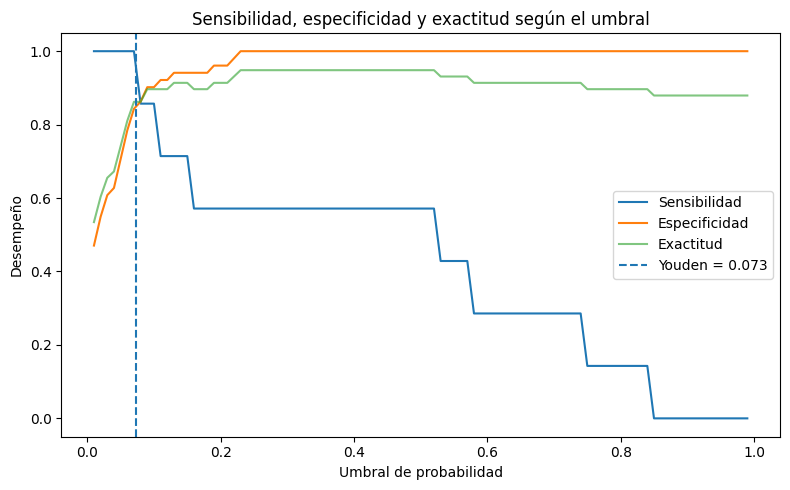


3. DECISION CURVE ANALYSIS


,threshold,net_benefit_model,net_benefit_all,net_benefit_none
0,0.01,0.115987,0.111808,0
1,0.02,0.112597,0.102745,0
2,0.03,0.110025,0.093494,0
3,0.04,0.107040,0.084052,0
4,0.05,0.107078,0.074410,0
5,0.06,0.108584,0.064563,0
6,0.07,0.110308,0.054505,0
7,0.08,0.092954,0.044228,0
8,0.09,0.094922,0.033725,0
9,0.10,0.093870,0.022989,0


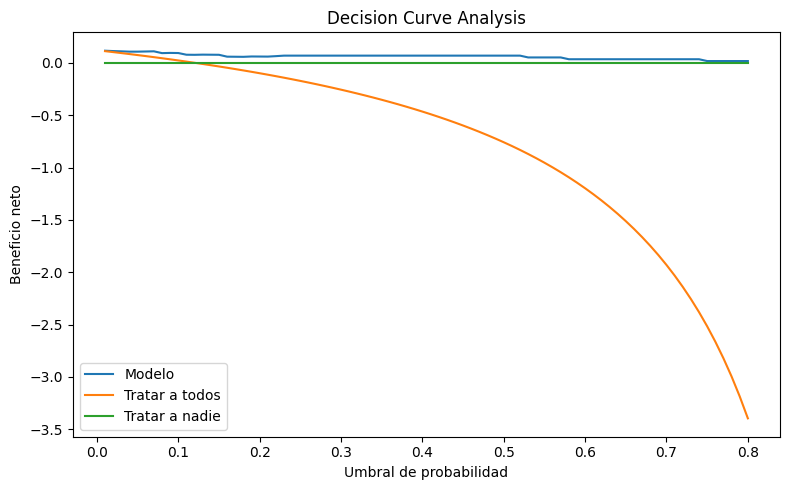


RESUMEN AUTOMÁTICO
El modelo tuvo un AUC de 0.958 en el set de prueba.
El umbral óptimo por Youden fue 0.073, con sensibilidad 1.000 y especificidad 0.863.
La curva sensibilidad/especificidad permite explorar puntos de corte alternativos según el objetivo clínico.
El decision curve analysis evalúa si usar el modelo aporta beneficio neto frente a tratar a todos o a nadie.


In [20]:
# =========================================================
# UMBRAL ÓPTIMO (YOUDEN) + CURVA SENSIBILIDAD/ESPECIFICIDAD + DCA
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, confusion_matrix, roc_auc_score

# ---------------------------------------------------------
# 0. VERIFICAR OBJETOS NECESARIOS
# ---------------------------------------------------------
# Se asume que ya existen:
# - modelo_final_test
# - X_test_sm
# - y_test
# - prob_test
#
# Si no existe prob_test, lo generamos:
try:
    prob_test
except NameError:
    prob_test = modelo_final_test.predict(X_test_sm)

y_test_np = np.array(y_test)

# ---------------------------------------------------------
# 1. OPTIMIZACIÓN DE UMBRAL POR ÍNDICE DE YOUDEN
# ---------------------------------------------------------
# Fundamento:
# Youden = Sensibilidad + Especificidad - 1
# El umbral óptimo maximiza ese equilibrio.

fpr, tpr, thresholds = roc_curve(y_test_np, prob_test)

youden_index = tpr - fpr
best_idx = np.argmax(youden_index)
best_threshold = thresholds[best_idx]

best_sensitivity = tpr[best_idx]
best_specificity = 1 - fpr[best_idx]
best_youden = youden_index[best_idx]
auc_test = roc_auc_score(y_test_np, prob_test)

print("\n====================")
print("1. UMBRAL ÓPTIMO POR ÍNDICE DE YOUDEN")
print("====================")
print(f"AUC: {auc_test:.3f}")
print(f"Umbral óptimo: {best_threshold:.3f}")
print(f"Sensibilidad: {best_sensitivity:.3f}")
print(f"Especificidad: {best_specificity:.3f}")
print(f"Youden index: {best_youden:.3f}")

# Matriz de confusión en el umbral óptimo
pred_youden = (prob_test >= best_threshold).astype(int)
cm_youden = confusion_matrix(y_test_np, pred_youden)
tn, fp, fn, tp = cm_youden.ravel()

print("\nMatriz de confusión (umbral óptimo):")
print(cm_youden)

# ---------------------------------------------------------
# 2. CURVA DE SENSIBILIDAD Y ESPECIFICIDAD SEGÚN EL UMBRAL
# ---------------------------------------------------------
# Fundamento:
# Muestra el trade-off entre detectar eventos y evitar falsos positivos.

threshold_grid = np.linspace(0.01, 0.99, 99)

sens_list = []
spec_list = []
acc_list = []

for thr in threshold_grid:
    pred_thr = (prob_test >= thr).astype(int)
    cm = confusion_matrix(y_test_np, pred_thr, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    sens = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    acc = (tp + tn) / (tp + tn + fp + fn)

    sens_list.append(sens)
    spec_list.append(spec)
    acc_list.append(acc)

threshold_perf = pd.DataFrame({
    "threshold": threshold_grid,
    "sensitivity": sens_list,
    "specificity": spec_list,
    "accuracy": acc_list
})

print("\n====================")
print("2. TABLA DE RENDIMIENTO SEGÚN UMBRAL")
print("====================")
display(threshold_perf.head(10))

plt.figure(figsize=(8,5))
plt.plot(threshold_perf["threshold"], threshold_perf["sensitivity"], label="Sensibilidad")
plt.plot(threshold_perf["threshold"], threshold_perf["specificity"], label="Especificidad")
plt.plot(threshold_perf["threshold"], threshold_perf["accuracy"], label="Exactitud", alpha=0.6)
plt.axvline(best_threshold, linestyle="--", label=f"Youden = {best_threshold:.3f}")
plt.xlabel("Umbral de probabilidad")
plt.ylabel("Desempeño")
plt.title("Sensibilidad, especificidad y exactitud según el umbral")
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. DECISION CURVE ANALYSIS (DCA)
# ---------------------------------------------------------
# Fundamento:
# Compara el beneficio neto del modelo versus:
# - tratar a todos
# - tratar a nadie
#
# Fórmula:
# Net Benefit = TP/n - FP/n * (pt / (1 - pt))

thresholds_dca = np.arange(0.01, 0.81, 0.01)

n = len(y_test_np)
prevalence = y_test_np.mean()

nb_model = []
nb_all = []
nb_none = []

for pt in thresholds_dca:
    pred_pt = (prob_test >= pt).astype(int)
    cm = confusion_matrix(y_test_np, pred_pt, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    # Beneficio neto del modelo
    nb_m = (tp / n) - (fp / n) * (pt / (1 - pt))
    nb_model.append(nb_m)

    # Beneficio neto de tratar a todos
    nb_a = prevalence - (1 - prevalence) * (pt / (1 - pt))
    nb_all.append(nb_a)

    # Beneficio neto de tratar a nadie
    nb_none.append(0)

dca_df = pd.DataFrame({
    "threshold": thresholds_dca,
    "net_benefit_model": nb_model,
    "net_benefit_all": nb_all,
    "net_benefit_none": nb_none
})

print("\n====================")
print("3. DECISION CURVE ANALYSIS")
print("====================")
display(dca_df.head(10))

plt.figure(figsize=(8,5))
plt.plot(dca_df["threshold"], dca_df["net_benefit_model"], label="Modelo")
plt.plot(dca_df["threshold"], dca_df["net_benefit_all"], label="Tratar a todos")
plt.plot(dca_df["threshold"], dca_df["net_benefit_none"], label="Tratar a nadie")
plt.xlabel("Umbral de probabilidad")
plt.ylabel("Beneficio neto")
plt.title("Decision Curve Analysis")
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4. RESUMEN AUTOMÁTICO
# ---------------------------------------------------------
print("\n====================")
print("RESUMEN AUTOMÁTICO")
print("====================")
print(f"El modelo tuvo un AUC de {auc_test:.3f} en el set de prueba.")
print(f"El umbral óptimo por Youden fue {best_threshold:.3f}, con sensibilidad {best_sensitivity:.3f} y especificidad {best_specificity:.3f}.")
print("La curva sensibilidad/especificidad permite explorar puntos de corte alternativos según el objetivo clínico.")
print("El decision curve analysis evalúa si usar el modelo aporta beneficio neto frente a tratar a todos o a nadie.")

In [21]:
# =========================================================
# COMPLETE SCRIPT: LOAD DATA + CLEAN DATA + FINAL MODEL + BOOTSTRAP VALIDATION
# =========================================================

import os
import glob
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score, brier_score_loss

# ---------------------------------------------------------
# 1. MOUNT GOOGLE DRIVE
# ---------------------------------------------------------
from google.colab import drive
drive.mount('/content/drive')

# ---------------------------------------------------------
# 2. FIND THE EXCEL FILE AUTOMATICALLY
# ---------------------------------------------------------
# Adjust the filename here if needed
target_filename = "Displasia broncopulmonar version original V2.xlsx"

search_roots = [
    "/content/drive/MyDrive",
    "/content"
]

found_paths = []

for root in search_roots:
    for path in glob.glob(os.path.join(root, "**", target_filename), recursive=True):
        found_paths.append(path)

print("Files found:")
for p in found_paths:
    print("-", p)

if len(found_paths) == 0:
    raise FileNotFoundError(
        f"No se encontró el archivo '{target_filename}'. "
        f"Verifica el nombre exacto o súbelo directamente a Colab."
    )

# If multiple files are found, use the first one
file_path = found_paths[0]
print("\nUsing file:")
print(file_path)

# ---------------------------------------------------------
# 3. LOAD EXCEL FILE
# ---------------------------------------------------------
xls = pd.ExcelFile(file_path)
print("\nAvailable sheets:", xls.sheet_names)

sheet_to_use = "Edited"
if sheet_to_use not in xls.sheet_names:
    raise ValueError(f"La hoja '{sheet_to_use}' no existe. Hojas disponibles: {xls.sheet_names}")

df = pd.read_excel(file_path, sheet_name=sheet_to_use)

print("\nOriginal dataset shape:", df.shape)
display(df.head())

# ---------------------------------------------------------
# 4. RENAME VARIABLES IF NEEDED
# ---------------------------------------------------------
# This step helps if the file still has long original names.
rename_candidates = {
    "Identificación del paciente (número de historia clínica, pegado, sin comas ni puntos, número entero)": "id_paciente",
    "Death": "outcome_final",
    "¿El paciente murió durante la hospitalización?": "outcome_final_alt",
    "Peso documentado en sala de partos en gramos (números enteros sin decimales ni signos de puntuación)": "peso_nacer_g",
    "Puntaje APGAR a los 5 minutos de vida": "apgar_5",
    "¿Fue el paciente prematuro extremo? (edad gestacional al nacimiento menor de 28 semanas)": "prematuro_extremo"
}

rename_dict = {k: v for k, v in rename_candidates.items() if k in df.columns}
df = df.rename(columns=rename_dict)

print("\nRenamed columns:")
print(rename_dict)

# ---------------------------------------------------------
# 5. DEFINE ANALYTIC VARIABLES
# ---------------------------------------------------------
# We try both possible outcome names if necessary
candidate_outcomes = ["outcome_final", "outcome_final_alt"]
outcome_var = None

for c in candidate_outcomes:
    if c in df.columns:
        outcome_var = c
        break

if outcome_var is None:
    raise ValueError("No se encontró la variable de outcome ('Death' o equivalente).")

required_vars = ["peso_nacer_g", "apgar_5", "prematuro_extremo", outcome_var]

missing_required = [v for v in required_vars if v not in df.columns]
if len(missing_required) > 0:
    raise ValueError(f"Faltan variables requeridas: {missing_required}")

df_clean = df[required_vars].copy()
df_clean = df_clean.rename(columns={outcome_var: "outcome_final"})

# Force numeric conversion
for col in ["peso_nacer_g", "apgar_5", "prematuro_extremo", "outcome_final"]:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

# Drop missing
df_clean = df_clean.dropna().copy()

# If binary variables are floats, make them int
df_clean["prematuro_extremo"] = df_clean["prematuro_extremo"].round().astype(int)
df_clean["outcome_final"] = df_clean["outcome_final"].round().astype(int)

print("\nClean dataset shape:", df_clean.shape)
print("Events:", int(df_clean["outcome_final"].sum()))
display(df_clean.head())

# ---------------------------------------------------------
# 6. FINAL MODEL IN THE FULL SAMPLE
# ---------------------------------------------------------
final_vars = ["peso_nacer_g", "apgar_5", "prematuro_extremo"]

X_orig = df_clean[final_vars].reset_index(drop=True)
y_orig = df_clean["outcome_final"].reset_index(drop=True)

X_orig_sm = sm.add_constant(X_orig, has_constant="add")
model_orig = sm.Logit(y_orig, X_orig_sm).fit(disp=0)

print("\n====================")
print("FINAL MODEL - FULL SAMPLE")
print("====================")
print(model_orig.summary())

# ---------------------------------------------------------
# 7. APPARENT PERFORMANCE
# ---------------------------------------------------------
p_orig = model_orig.predict(X_orig_sm)

auc_apparent = roc_auc_score(y_orig, p_orig)
brier_apparent = brier_score_loss(y_orig, p_orig)

eps = 1e-12
p_orig_clip = np.clip(p_orig, eps, 1 - eps)
lp_orig = np.log(p_orig_clip / (1 - p_orig_clip))

cal_model_orig = sm.Logit(y_orig, sm.add_constant(lp_orig, has_constant="add")).fit(disp=0)
cal_intercept_apparent = cal_model_orig.params.iloc[0]
cal_slope_apparent = cal_model_orig.params.iloc[1]

print("\n====================")
print("APPARENT PERFORMANCE")
print("====================")
print(f"AUC apparent: {auc_apparent:.4f}")
print(f"Brier apparent: {brier_apparent:.4f}")
print(f"Calibration intercept apparent: {cal_intercept_apparent:.4f}")
print(f"Calibration slope apparent: {cal_slope_apparent:.4f}")

# ---------------------------------------------------------
# 8. BOOTSTRAP VALIDATION
# ---------------------------------------------------------
def fit_logit_model(X, y):
    X_sm = sm.add_constant(X, has_constant="add")
    model = sm.Logit(y, X_sm).fit(disp=0)
    return model

n = len(df_clean)
B = 500

optimism_auc = []
optimism_brier = []
optimism_slope = []
optimism_intercept = []
failed_replicates = 0

for b in range(B):
    idx_boot = np.random.choice(np.arange(n), size=n, replace=True)
    X_boot = X_orig.iloc[idx_boot].reset_index(drop=True)
    y_boot = y_orig.iloc[idx_boot].reset_index(drop=True)

    try:
        model_boot = fit_logit_model(X_boot, y_boot)
    except Exception:
        failed_replicates += 1
        continue

    try:
        # Performance in bootstrap sample
        X_boot_sm = sm.add_constant(X_boot, has_constant="add")
        p_boot_in = model_boot.predict(X_boot_sm)

        auc_boot_in = roc_auc_score(y_boot, p_boot_in)
        brier_boot_in = brier_score_loss(y_boot, p_boot_in)

        p_boot_in_clip = np.clip(p_boot_in, eps, 1 - eps)
        lp_boot_in = np.log(p_boot_in_clip / (1 - p_boot_in_clip))

        cal_boot_in = sm.Logit(
            y_boot,
            sm.add_constant(lp_boot_in, has_constant="add")
        ).fit(disp=0)

        intercept_boot_in = cal_boot_in.params.iloc[0]
        slope_boot_in = cal_boot_in.params.iloc[1]

        # Test performance in original sample
        p_boot_test = model_boot.predict(X_orig_sm)

        auc_boot_test = roc_auc_score(y_orig, p_boot_test)
        brier_boot_test = brier_score_loss(y_orig, p_boot_test)

        p_boot_test_clip = np.clip(p_boot_test, eps, 1 - eps)
        lp_boot_test = np.log(p_boot_test_clip / (1 - p_boot_test_clip))

        cal_boot_test = sm.Logit(
            y_orig,
            sm.add_constant(lp_boot_test, has_constant="add")
        ).fit(disp=0)

        intercept_boot_test = cal_boot_test.params.iloc[0]
        slope_boot_test = cal_boot_test.params.iloc[1]

        # Optimism
        optimism_auc.append(auc_boot_in - auc_boot_test)
        optimism_brier.append(brier_boot_in - brier_boot_test)
        optimism_intercept.append(intercept_boot_in - intercept_boot_test)
        optimism_slope.append(slope_boot_in - slope_boot_test)

    except Exception:
        failed_replicates += 1
        continue

mean_opt_auc = np.mean(optimism_auc)
mean_opt_brier = np.mean(optimism_brier)
mean_opt_intercept = np.mean(optimism_intercept)
mean_opt_slope = np.mean(optimism_slope)

auc_corrected = auc_apparent - mean_opt_auc
brier_corrected = brier_apparent - mean_opt_brier
cal_intercept_corrected = cal_intercept_apparent - mean_opt_intercept
cal_slope_corrected = cal_slope_apparent - mean_opt_slope
shrinkage_factor = cal_slope_corrected

print("\n====================")
print("BOOTSTRAP-VALIDATED PERFORMANCE")
print("====================")
print(f"Valid bootstrap replicates: {len(optimism_auc)}")
print(f"Failed bootstrap replicates: {failed_replicates}")
print(f"Mean optimism AUC: {mean_opt_auc:.4f}")
print(f"Optimism-corrected AUC: {auc_corrected:.4f}")
print(f"Mean optimism Brier: {mean_opt_brier:.4f}")
print(f"Optimism-corrected Brier: {brier_corrected:.4f}")
print(f"Mean optimism calibration intercept: {mean_opt_intercept:.4f}")
print(f"Optimism-corrected calibration intercept: {cal_intercept_corrected:.4f}")
print(f"Mean optimism calibration slope: {mean_opt_slope:.4f}")
print(f"Optimism-corrected calibration slope: {cal_slope_corrected:.4f}")
print(f"Estimated global shrinkage factor: {shrinkage_factor:.4f}")

# ---------------------------------------------------------
# 9. SUMMARY TABLE
# ---------------------------------------------------------
bootstrap_results = pd.DataFrame({
    "Metric": [
        "Apparent AUC",
        "Mean optimism AUC",
        "Optimism-corrected AUC",
        "Apparent Brier score",
        "Mean optimism Brier score",
        "Optimism-corrected Brier score",
        "Apparent calibration intercept",
        "Optimism-corrected calibration intercept",
        "Apparent calibration slope",
        "Optimism-corrected calibration slope",
        "Global shrinkage factor"
    ],
    "Value": [
        auc_apparent,
        mean_opt_auc,
        auc_corrected,
        brier_apparent,
        mean_opt_brier,
        brier_corrected,
        cal_intercept_apparent,
        cal_intercept_corrected,
        cal_slope_apparent,
        cal_slope_corrected,
        shrinkage_factor
    ]
})

bootstrap_results["Value"] = bootstrap_results["Value"].round(4)

print("\n====================")
print("BOOTSTRAP SUMMARY TABLE")
print("====================")
display(bootstrap_results)

# ---------------------------------------------------------
# 10. SHRUNK COEFFICIENTS
# ---------------------------------------------------------
orig_params = model_orig.params.copy()
shrunk_params = orig_params.copy()

for var in final_vars:
    shrunk_params[var] = orig_params[var] * shrinkage_factor

lp_shrunk_no_intercept = np.dot(X_orig[final_vars], shrunk_params[final_vars])
mean_lp_shrunk = lp_shrunk_no_intercept.mean()
mean_y = y_orig.mean()

shrunk_intercept = np.log(mean_y / (1 - mean_y)) - mean_lp_shrunk
shrunk_params["const"] = shrunk_intercept

shrunk_table = pd.DataFrame({
    "Variable": shrunk_params.index,
    "Original coefficient": orig_params.values,
    "Shrunk coefficient": shrunk_params.values
}).round(4)

print("\n====================")
print("SHRUNK COEFFICIENTS")
print("====================")
display(shrunk_table)

# ---------------------------------------------------------
# 11. OPTIONAL: PREDICTION WITH SHRUNK COEFFICIENTS
# ---------------------------------------------------------
def predict_risk_shrunk(birth_weight_g, apgar5, extreme_prematurity):
    logit = (
        shrunk_params["const"]
        + shrunk_params["peso_nacer_g"] * birth_weight_g
        + shrunk_params["apgar_5"] * apgar5
        + shrunk_params["prematuro_extremo"] * extreme_prematurity
    )
    risk = 1 / (1 + np.exp(-logit))
    return {
        "logit": round(float(logit), 4),
        "predicted_risk": round(float(risk), 4)
    }

example_shrunk = predict_risk_shrunk(
    birth_weight_g=800,
    apgar5=6,
    extreme_prematurity=1
)

print("\n====================")
print("EXAMPLE USING SHRUNK COEFFICIENTS")
print("====================")
print(example_shrunk)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files found:
- /content/drive/MyDrive/Drive/En proceso de publicacion/ARTICULOS PRIMERA Y SEGUNDA FASE/PRIMERA FASE/DBP/Bolivariana/Displasia broncopulmonar version original V2.xlsx
- /content/drive/MyDrive/Drive/En proceso de publicacion/ARTICULOS PRIMERA Y SEGUNDA FASE/PRIMERA FASE/DBP/Bolivariana/Displasia broncopulmonar version original V2.xlsx

Using file:
/content/drive/MyDrive/Drive/En proceso de publicacion/ARTICULOS PRIMERA Y SEGUNDA FASE/PRIMERA FASE/DBP/Bolivariana/Displasia broncopulmonar version original V2.xlsx

Available sheets: ['Edited']

Original dataset shape: (236, 104)


,ID,"Identificación del paciente (número de historia clínica, pegado, sin comas ni puntos, número entero)",Días de estancia hospitalaria:,"Días totales de estancia en UCI (contar solo los días de UCIN, no UCEN ni básicos)",Estrato socio-económico de la madre,Escolaridad materna,"Edad de la madre (años cumplidos, solo números enteros, sin comas ni números)",Procedencia de la madre,EPS,La madre tiene historia personal de Diabetes Mellitus:,...,El paciente fue dado de alta antes de la semana 36,¿El paciente presentó anemia con requerimiento transfusional durante la hospitalización?,Percentil documentado en la historia clínica del nacimiento de la talla al nacer según Intergrowth (usar un solo decimal separado por un punto),La madre tiene historia de preeclampsia 0 grave durante la gestación:,La madre tiene historia de preeclampsia grave durante la gestación:,La madre tiene historia de 1ndrome de HELLP o eclampsia durante la gestación:,Causa de la prematurez del bebé,"El paciente tiene diagnóstico de DBP potencialmente fatal: es definida como uso de presión positiva (IOT, VNI) o uso de vasodilatadores pulmonares a la semana 38",Death,Cuál fue la causa de muerte descrita en la historia clínica
0,1.0,818989.0,45.0,20.0,1.0,NaN,18.0,1.0,1.0,0.0,...,1.0,1.0,38.2,0.0,0.0,0.0,1.0,0.0,0.0,NaN
1,2.0,823985.0,2.0,2.0,NaN,NaN,17.0,1.0,0.0,0.0,...,0.0,0.0,93.7,0.0,0.0,0.0,0.0,NaN,1.0,3.0
2,3.0,823986.0,4.0,4.0,NaN,NaN,17.0,1.0,0.0,0.0,...,0.0,1.0,12.2,0.0,0.0,0.0,0.0,NaN,1.0,2.0
3,4.0,862825.0,75.0,48.0,NaN,1.0,34.0,0.0,0.0,0.0,...,1.0,1.0,77.2,0.0,1.0,0.0,1.0,NaN,0.0,NaN
4,5.0,872268.0,36.0,14.0,0.0,1.0,21.0,0.0,0.0,0.0,...,0.0,1.0,21.9,1.0,1.0,0.0,0.0,0.0,0.0,NaN



Renamed columns:
{'Identificación del paciente (número de historia clínica, pegado, sin comas ni puntos, número entero)': 'id_paciente', 'Death': 'outcome_final', '¿El paciente murió durante la hospitalización?': 'outcome_final_alt', 'Peso documentado en sala de partos en gramos (números enteros sin decimales ni signos de puntuación)': 'peso_nacer_g', 'Puntaje APGAR a los 5 minutos de vida': 'apgar_5', '¿Fue el paciente prematuro extremo? (edad gestacional al nacimiento menor de 28 semanas)': 'prematuro_extremo'}

Clean dataset shape: (233, 4)
Events: 26


,peso_nacer_g,apgar_5,prematuro_extremo,outcome_final
0,1185.0,8.0,0,0
1,1125.0,7.0,0,1
2,675.0,8.0,0,1
3,885.0,9.0,1,0
4,1247.0,5.0,0,0



FINAL MODEL - FULL SAMPLE
                           Logit Regression Results                           
Dep. Variable:          outcome_final   No. Observations:                  233
Model:                          Logit   Df Residuals:                      229
Method:                           MLE   Df Model:                            3
Date:                Mon, 20 Apr 2026   Pseudo R-squ.:                  0.4239
Time:                        02:44:54   Log-Likelihood:                -46.954
converged:                       True   LL-Null:                       -81.509
Covariance Type:            nonrobust   LLR p-value:                 6.625e-15
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 7.2295      2.271      3.183      0.001       2.778      11.681
peso_nacer_g         -0.0066      0.002     -3.936      0.000      -0.010      -0.0

,Metric,Value
0,Apparent AUC,0.9195
1,Mean optimism AUC,0.0056
2,Optimism-corrected AUC,0.9139
3,Apparent Brier score,0.0599
4,Mean optimism Brier score,-0.0049
5,Optimism-corrected Brier score,0.0648
6,Apparent calibration intercept,0.0000
7,Optimism-corrected calibration intercept,-0.0252
8,Apparent calibration slope,1.0000
9,Optimism-corrected calibration slope,0.9396



SHRUNK COEFFICIENTS


,Variable,Original coefficient,Shrunk coefficient
0,const,7.2295,8.6126
1,peso_nacer_g,-0.0066,-0.0062
2,apgar_5,-0.4186,-0.3933
3,prematuro_extremo,0.8003,0.7520



EXAMPLE USING SHRUNK COEFFICIENTS
{'logit': 2.0173, 'predicted_risk': 0.8826}


Shrunk slopes:
Birth weight: -0.006056
Apgar 5: -0.384107
Extreme prematurity: 0.734355

Observed event rate: 0.1116
Recalibrated intercept: 6.513771

Clinical scenarios:


,Birth weight (g),Apgar 5,Extreme prematurity,Predicted risk (%)
0,700,5,0,58.8
1,700,5,1,74.8
2,700,7,0,39.8
3,700,7,1,57.9
4,700,9,0,23.5
5,700,9,1,39.0
6,800,5,0,43.7
7,800,5,1,61.8
8,800,7,0,26.5
9,800,7,1,42.9



Example patient: 800 g, Apgar 6, extreme prematurity = Yes
{'logit': 0.0986, 'predicted_risk': 0.5246}


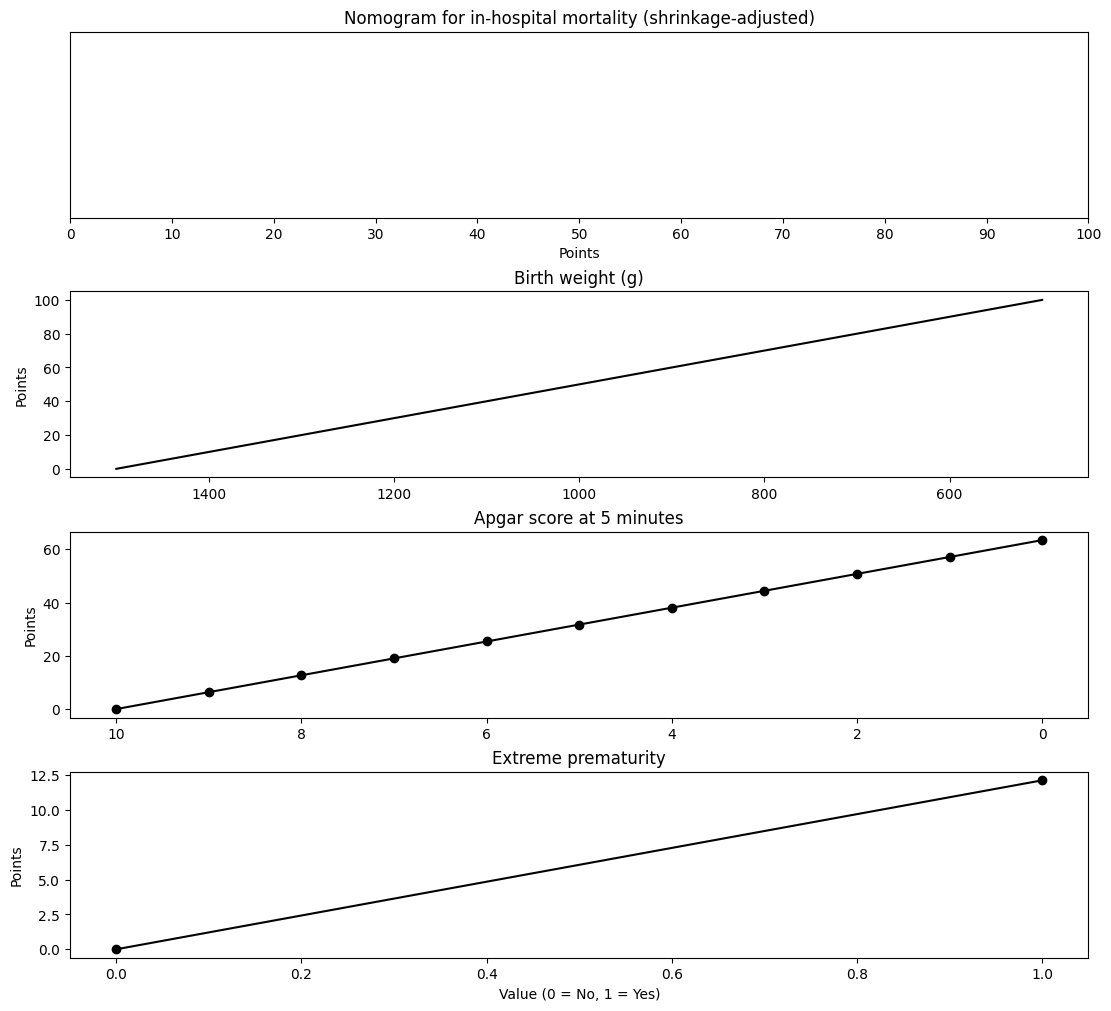

In [23]:
# =========================================================
# FINAL SHRUNK MODEL + CORRECT INTERCEPT RECALIBRATION
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# ---------------------------------------------------------
# 1. COEFICIENTES ORIGINALES DEL MODELO FINAL
#    (usar los tuyos exactos del modelo completo)
# ---------------------------------------------------------
beta0_orig = 7.2295
beta_bw_orig = -0.0066
beta_apgar_orig = -0.4186
beta_extreme_orig = 0.8003

# Shrinkage factor obtenido por bootstrap
shrinkage_factor = 0.9176

# ---------------------------------------------------------
# 2. APLICAR SHRINKAGE A LOS PREDICTORES
# ---------------------------------------------------------
beta_bw = beta_bw_orig * shrinkage_factor
beta_apgar = beta_apgar_orig * shrinkage_factor
beta_extreme = beta_extreme_orig * shrinkage_factor

print("Shrunk slopes:")
print("Birth weight:", round(beta_bw, 6))
print("Apgar 5:", round(beta_apgar, 6))
print("Extreme prematurity:", round(beta_extreme, 6))

# ---------------------------------------------------------
# 3. RECONSTRUIR LA BASE ANALÍTICA
#    df_clean debe existir y contener:
#    peso_nacer_g, apgar_5, prematuro_extremo, outcome_final
# ---------------------------------------------------------
final_vars = ["peso_nacer_g", "apgar_5", "prematuro_extremo"]

X = df_clean[final_vars].copy()
y = df_clean["outcome_final"].astype(int).copy()

# predictor lineal SIN intercepto
lp_no_intercept = (
    beta_bw * X["peso_nacer_g"].values
    + beta_apgar * X["apgar_5"].values
    + beta_extreme * X["prematuro_extremo"].values
)

observed_prevalence = y.mean()
print("\nObserved event rate:", round(observed_prevalence, 4))

# ---------------------------------------------------------
# 4. RECALIBRAR INTERCEPTO CORRECTAMENTE
#    Buscamos beta0 tal que:
#    mean(sigmoid(beta0 + lp_no_intercept)) = prevalencia observada
# ---------------------------------------------------------
def mean_pred_minus_obs(beta0):
    p = 1 / (1 + np.exp(-(beta0 + lp_no_intercept)))
    return p.mean() - observed_prevalence

beta0_recal = brentq(mean_pred_minus_obs, -20, 20)

print("Recalibrated intercept:", round(beta0_recal, 6))

# ---------------------------------------------------------
# 5. FUNCIÓN FINAL DE RIESGO
# ---------------------------------------------------------
def predict_risk_final(birth_weight_g, apgar5, extreme_prematurity):
    logit = (
        beta0_recal
        + beta_bw * birth_weight_g
        + beta_apgar * apgar5
        + beta_extreme * extreme_prematurity
    )
    risk = 1 / (1 + np.exp(-logit))
    return {
        "logit": round(float(logit), 4),
        "predicted_risk": round(float(risk), 4)
    }

# ---------------------------------------------------------
# 6. PROBAR ESCENARIOS CLÍNICOS
# ---------------------------------------------------------
scenarios = []

for bw in [700, 800, 900, 1000, 1200, 1500]:
    for apgar in [5, 7, 9]:
        for extreme in [0, 1]:
            out = predict_risk_final(bw, apgar, extreme)
            scenarios.append({
                "Birth weight (g)": bw,
                "Apgar 5": apgar,
                "Extreme prematurity": extreme,
                "Predicted risk (%)": round(out["predicted_risk"] * 100, 1)
            })

df_scenarios = pd.DataFrame(scenarios)

print("\nClinical scenarios:")
display(df_scenarios)

# ---------------------------------------------------------
# 7. EJEMPLO CLAVE
# ---------------------------------------------------------
example = predict_risk_final(800, 6, 1)
print("\nExample patient: 800 g, Apgar 6, extreme prematurity = Yes")
print(example)

# ---------------------------------------------------------
# 8. NOMOGRAMA DE PUNTOS (solo representación relativa)
# ---------------------------------------------------------
# Impacto relativo dentro de rangos clínicos razonables
bw_min, bw_max = 500, 1500
apgar_min, apgar_max = 0, 10
extreme_min, extreme_max = 0, 1

impact_bw = abs(beta_bw * (bw_min - bw_max))
impact_apgar = abs(beta_apgar * (apgar_min - apgar_max))
impact_extreme = abs(beta_extreme * (extreme_max - extreme_min))

max_impact = max(impact_bw, impact_apgar, impact_extreme)

bw_range = np.linspace(bw_min, bw_max, 100)
bw_points = abs(beta_bw * (bw_range - bw_max)) / max_impact * 100

apgar_range = np.arange(apgar_min, apgar_max + 1)
apgar_points = abs(beta_apgar * (apgar_range - apgar_max)) / max_impact * 100

extreme_vals = np.array([0, 1])
extreme_points = abs(beta_extreme * extreme_vals) / max_impact * 100

# ---------------------------------------------------------
# 9. FIGURA MEJORADA DEL NOMOGRAMA
# ---------------------------------------------------------
fig, axes = plt.subplots(4, 1, figsize=(11, 10), constrained_layout=True)

# Escala general de puntos
axes[0].set_xlim(0, 100)
axes[0].set_ylim(0, 1)
axes[0].set_yticks([])
axes[0].set_xticks(np.arange(0, 101, 10))
axes[0].set_title("Nomogram for in-hospital mortality (shrinkage-adjusted)")
axes[0].set_xlabel("Points")

# Birth weight
axes[1].plot(bw_range, bw_points, color="black")
axes[1].invert_xaxis()
axes[1].set_title("Birth weight (g)")
axes[1].set_ylabel("Points")

# Apgar 5
axes[2].plot(apgar_range, apgar_points, marker="o", color="black")
axes[2].invert_xaxis()
axes[2].set_title("Apgar score at 5 minutes")
axes[2].set_ylabel("Points")

# Extreme prematurity
axes[3].plot(extreme_vals, extreme_points, marker="o", color="black")
axes[3].set_title("Extreme prematurity")
axes[3].set_ylabel("Points")
axes[3].set_xlabel("Value (0 = No, 1 = Yes)")

plt.show()